In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import os
import time

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AIS_2017_01_10.csv')

In [ ]:
print("\n===== BASIC INFO =====")
print("Total records   :", len(df))
print("Columns         :", df.columns.tolist())

print("\n===== DATA QUALITY =====")
print("Null counts:\n", df.isnull().sum())

if 'SOG' in df.columns:
    print("\nSOG range       :", df['SOG'].min(), "to", df['SOG'].max())
    print("SOG < 0 count   :", (df['SOG'] < 0).sum())
    print("SOG > 30 count  :", (df['SOG'] > 30).sum())

if 'COG' in df.columns:
    print("\nCOG range       :", df['COG'].min(), "to", df['COG'].max())
    print("Negative COG    :", (df['COG'] < 0).sum())

if 'Heading' in df.columns:
    print("\nHeading = 511   :", (df['Heading'] == 511).sum())
    print("Heading range   :", df['Heading'].min(), "to", df['Heading'].max())

print("\n===== SHIP COUNTS =====")
per_ship = df.groupby('MMSI').size().sort_values(ascending=False)
print("Total unique ships      :", len(per_ship))
print("Ships with 900+ records :", (per_ship >= 900).sum())
print("Ships with 500+ records :", (per_ship >= 500).sum())
print("Ships with 200+ records :", (per_ship >= 200).sum())

print("\nTop 25 ships by record count:")
print(per_ship.head(25).to_string())

if 'BaseDateTime' in df.columns:
    df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'], errors='coerce')
    print("\n===== DATE RANGE =====")
    print("From :", df['BaseDateTime'].min())
    print("To   :", df['BaseDateTime'].max())

if 'LAT' in df.columns and 'LON' in df.columns:
    print("\n===== GEOGRAPHIC COVERAGE =====")
    print("LAT range :", df['LAT'].min(), "to", df['LAT'].max())
    print("LON range :", df['LON'].min(), "to", df['LON'].max())



===== BASIC INFO =====
Total records   : 6949544
Columns         : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo']

===== DATA QUALITY =====
Null counts:
 MMSI                  0
BaseDateTime          0
LAT                   0
LON                   0
SOG                   0
COG                   0
Heading               0
VesselName       282409
IMO             4035664
CallSign         730452
VesselType       469619
Status          1068570
Length           719075
Width           1748231
Draft           4775742
Cargo           3900590
dtype: int64

SOG range       : 0.0 to 102.3
SOG < 0 count   : 0
SOG > 30 count  : 12642

COG range       : 0.0 to 360.0
Negative COG    : 0

Heading = 511   : 4032977
Heading range   : 0.0 to 511.0

===== SHIP COUNTS =====
Total unique ships      : 11176
Ships with 900+ records : 3487
Ships with 500+ records : 4979
Ships with 200+ records : 9109




===== BASIC INFO =====
Total records   : 6949544
Columns         : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo']

===== DATA QUALITY =====
Null counts:
 MMSI                  0
BaseDateTime          0
LAT                   0
LON                   0
SOG                   0
COG                   0
Heading               0
VesselName       282409
IMO             4035664
CallSign         730452
VesselType       469619
Status          1068570
Length           719075
Width           1748231
Draft           4775742
Cargo           3900590
dtype: int64


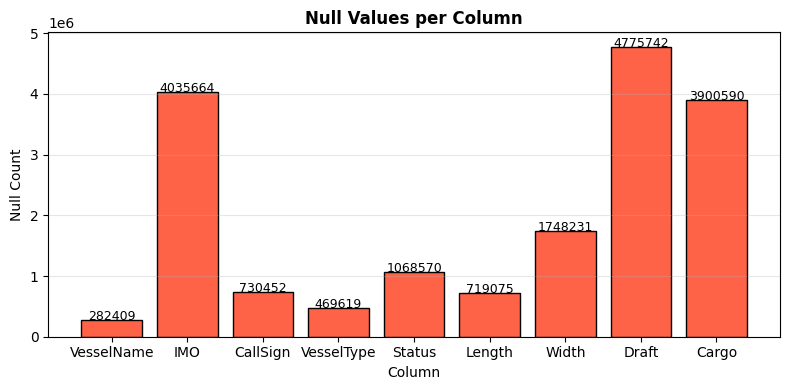


SOG range       : 0.0 to 102.3
SOG < 0 count   : 0
SOG > 30 count  : 12642


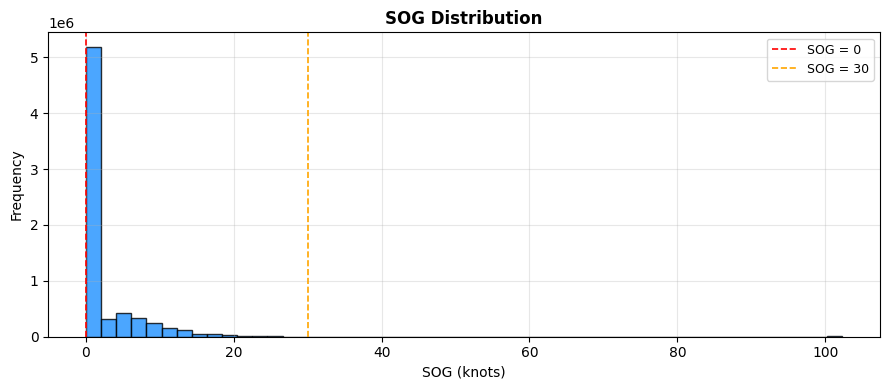


COG range       : 0.0 to 360.0
Negative COG    : 0


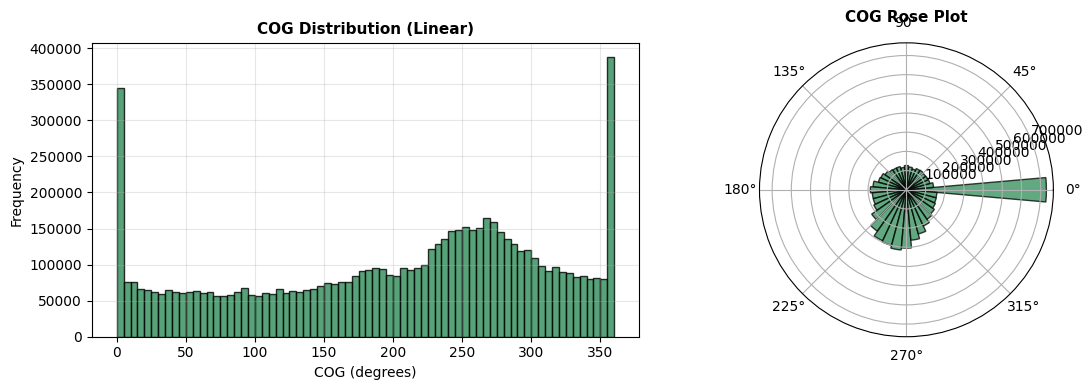


Heading = 511   : 4032977
Heading range   : 0.0 to 511.0


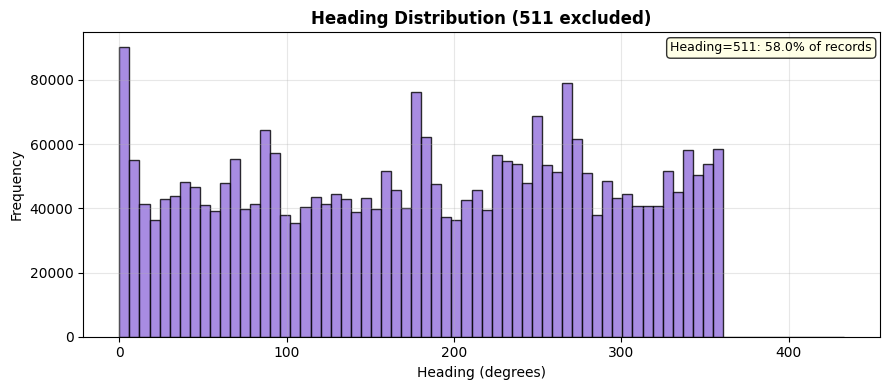


===== SHIP COUNTS =====
Total unique ships      : 11176
Ships with 900+ records : 3487
Ships with 500+ records : 4979
Ships with 200+ records : 9109

Top 25 ships by record count:
MMSI
316031266    1370
636013447    1364
367322740    1356
367314530    1354
367098550    1349
367033060    1348
367331730    1345
367032060    1345
367008020    1344
367047120    1344
367653630    1342
316003666    1338
367719170    1334
220402000    1334
367441530    1333
367608420    1333
367419960    1333
367450580    1332
367434360    1332
367170860    1331
366765940    1330
367530040    1329
367162190    1328
367384780    1327
367476050    1325


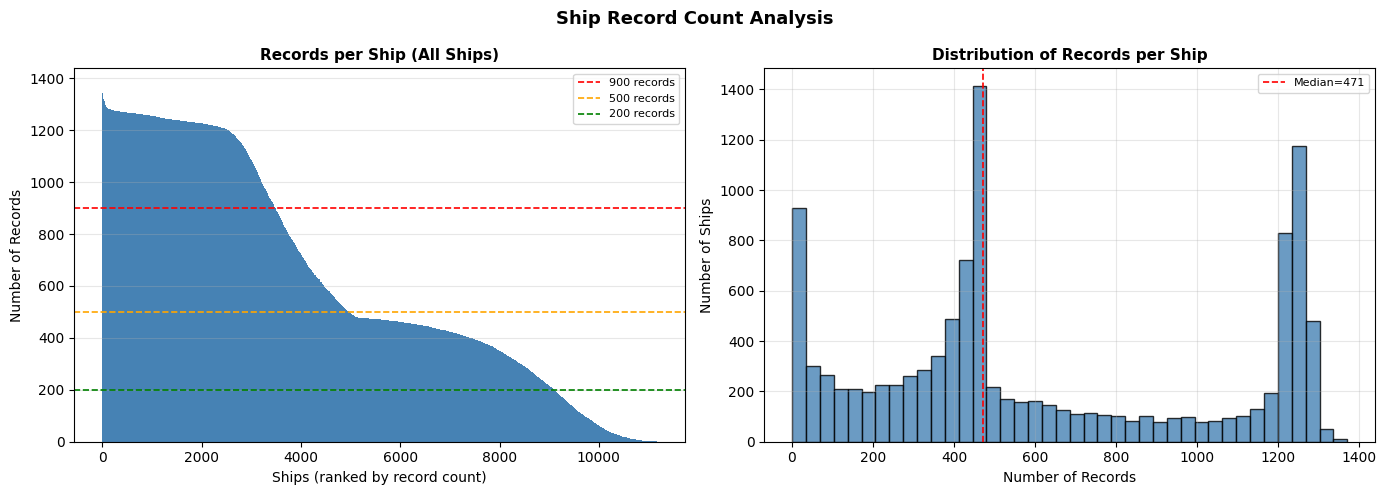


===== DATE RANGE =====
From : 2017-01-10 00:00:00
To   : 2017-01-10 23:59:59


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


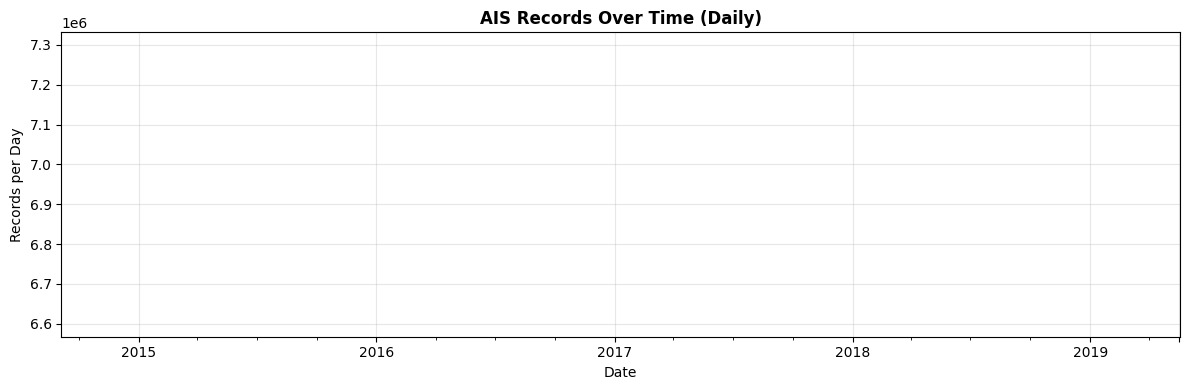


===== GEOGRAPHIC COVERAGE =====
LAT range : 0.36806 to 74.50766
LON range : -171.10681 to 147.94602


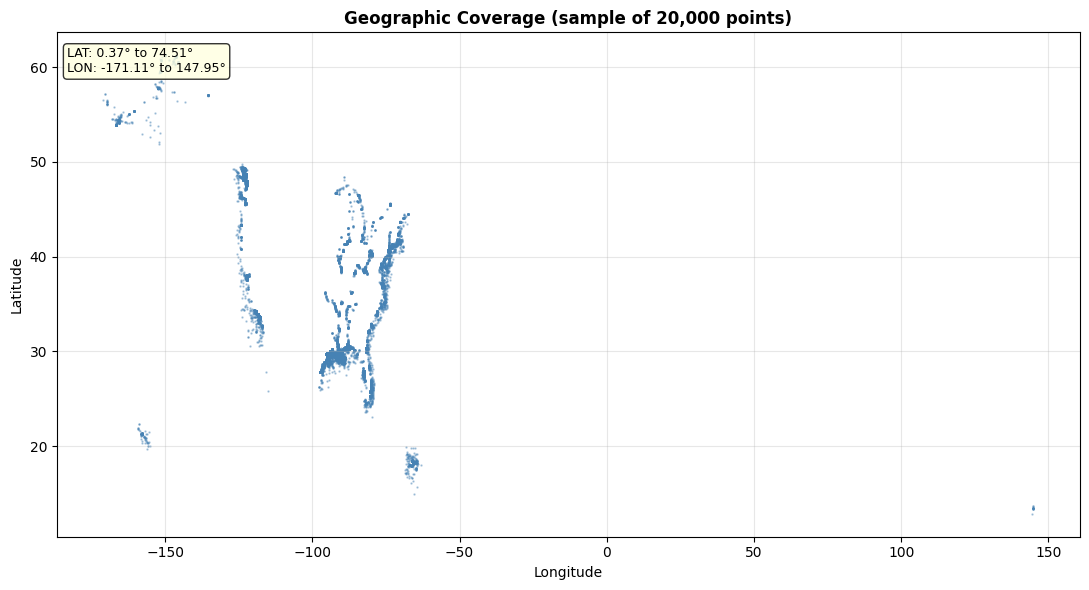

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n===== BASIC INFO =====")
print("Total records   :", len(df))
print("Columns         :", df.columns.tolist())

print("\n===== DATA QUALITY =====")
print("Null counts:\n", df.isnull().sum())

# ── Plot 1: Null counts per column ──────────────────────────
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(null_counts.index, null_counts.values, color='tomato', edgecolor='k')
    ax.set_xlabel('Column', fontsize=10)
    ax.set_ylabel('Null Count', fontsize=10)
    ax.set_title('Null Values per Column', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(null_counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("  ✅ No null values found — skipping null plot")

if 'SOG' in df.columns:
    print("\nSOG range       :", df['SOG'].min(), "to", df['SOG'].max())
    print("SOG < 0 count   :", (df['SOG'] < 0).sum())
    print("SOG > 30 count  :", (df['SOG'] > 30).sum())

    # ── Plot 2: SOG distribution ─────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(df['SOG'].dropna().values, bins=50,
            color='dodgerblue', edgecolor='k', alpha=0.8)
    ax.axvline(0,  color='red',    linestyle='--', linewidth=1.2, label='SOG = 0')
    ax.axvline(30, color='orange', linestyle='--', linewidth=1.2, label='SOG = 30')
    ax.set_xlabel('SOG (knots)', fontsize=10)
    ax.set_ylabel('Frequency',   fontsize=10)
    ax.set_title('SOG Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'COG' in df.columns:
    print("\nCOG range       :", df['COG'].min(), "to", df['COG'].max())
    print("Negative COG    :", (df['COG'] < 0).sum())

    # ── Plot 3: COG distribution (polar) ─────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df['COG'].dropna().values, bins=72,
                 color='seagreen', edgecolor='k', alpha=0.8)
    axes[0].set_xlabel('COG (degrees)', fontsize=10)
    axes[0].set_ylabel('Frequency',     fontsize=10)
    axes[0].set_title('COG Distribution (Linear)', fontsize=11, fontweight='bold')
    axes[0].grid(alpha=0.3)

    # Polar rose plot
    ax_polar = fig.add_subplot(122, projection='polar')
    cog_rad  = np.radians(df['COG'].dropna().values % 360)
    bins_pol = np.linspace(0, 2*np.pi, 37)
    counts, _ = np.histogram(cog_rad, bins=bins_pol)
    width    = bins_pol[1] - bins_pol[0]
    ax_polar.bar(bins_pol[:-1], counts, width=width,
                 color='seagreen', edgecolor='k', alpha=0.75)
    ax_polar.set_title('COG Rose Plot', fontsize=11, fontweight='bold', pad=15)
    axes[1].set_visible(False)   # hide the flat axes replaced by polar

    plt.tight_layout()
    plt.show()

if 'Heading' in df.columns:
    print("\nHeading = 511   :", (df['Heading'] == 511).sum())
    print("Heading range   :", df['Heading'].min(), "to", df['Heading'].max())

    # ── Plot 4: Heading distribution (excluding 511) ──────────
    valid_hdg = df[df['Heading'] != 511]['Heading'].dropna()
    fig, ax   = plt.subplots(figsize=(9, 4))
    ax.hist(valid_hdg.values, bins=72,
            color='mediumpurple', edgecolor='k', alpha=0.8)
    ax.set_xlabel('Heading (degrees)', fontsize=10)
    ax.set_ylabel('Frequency',         fontsize=10)
    ax.set_title('Heading Distribution (511 excluded)', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    pct_511 = (df['Heading'] == 511).mean() * 100
    ax.text(0.99, 0.97, f"Heading=511: {pct_511:.1f}% of records",
            transform=ax.transAxes, fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout()
    plt.show()

print("\n===== SHIP COUNTS =====")
per_ship = df.groupby('MMSI').size().sort_values(ascending=False)
print("Total unique ships      :", len(per_ship))
print("Ships with 900+ records :", (per_ship >= 900).sum())
print("Ships with 500+ records :", (per_ship >= 500).sum())
print("Ships with 200+ records :", (per_ship >= 200).sum())
print("\nTop 25 ships by record count:")
print(per_ship.head(25).to_string())

# ── Plot 5: Records per ship (ranked) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(per_ship)), per_ship.values,
            color='steelblue', edgecolor='none', width=1.0)
axes[0].axhline(900, color='red',    linestyle='--', linewidth=1.2, label='900 records')
axes[0].axhline(500, color='orange', linestyle='--', linewidth=1.2, label='500 records')
axes[0].axhline(200, color='green',  linestyle='--', linewidth=1.2, label='200 records')
axes[0].set_xlabel('Ships (ranked by record count)', fontsize=10)
axes[0].set_ylabel('Number of Records',              fontsize=10)
axes[0].set_title('Records per Ship (All Ships)',    fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

axes[1].hist(per_ship.values, bins=40,
             color='steelblue', edgecolor='k', alpha=0.8)
axes[1].set_xlabel('Number of Records', fontsize=10)
axes[1].set_ylabel('Number of Ships',   fontsize=10)
axes[1].set_title('Distribution of Records per Ship', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axvline(per_ship.median(), color='red', linestyle='--',
                linewidth=1.2, label=f'Median={per_ship.median():.0f}')
axes[1].legend(fontsize=8)

plt.suptitle('Ship Record Count Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if 'BaseDateTime' in df.columns:
    df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'], errors='coerce')
    print("\n===== DATE RANGE =====")
    print("From :", df['BaseDateTime'].min())
    print("To   :", df['BaseDateTime'].max())

    # ── Plot 6: Records over time ─────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    df.set_index('BaseDateTime').resample('D').size().plot(
        ax=ax, color='steelblue', linewidth=1.2)
    ax.set_xlabel('Date',               fontsize=10)
    ax.set_ylabel('Records per Day',    fontsize=10)
    ax.set_title('AIS Records Over Time (Daily)', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'LAT' in df.columns and 'LON' in df.columns:
    print("\n===== GEOGRAPHIC COVERAGE =====")
    print("LAT range :", df['LAT'].min(), "to", df['LAT'].max())
    print("LON range :", df['LON'].min(), "to", df['LON'].max())

    # ── Plot 7: Geographic scatter ────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))
    sample  = df[['LAT','LON']].dropna().sample(min(20000, len(df)), random_state=42)
    ax.scatter(sample['LON'], sample['LAT'],
               s=0.5, alpha=0.4, color='steelblue')
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude',  fontsize=10)
    ax.set_title(f'Geographic Coverage (sample of {len(sample):,} points)',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.text(0.01, 0.97,
            f"LAT: {df['LAT'].min():.2f}° to {df['LAT'].max():.2f}°\n"
            f"LON: {df['LON'].min():.2f}° to {df['LON'].max():.2f}°",
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout()
    plt.show()

In [ ]:



import pandas as pd
import numpy as np
import os
import time

FILE_PATH   = "/content/drive/MyDrive/AIS_2017_01_10.csv"
OUTPUT_DIR  = "/content/ais_output"
MIN_RECORDS = 700

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print("STEP 1: Loading raw data...")
print("=" * 60)
start = time.time()
df = pd.read_csv('/content/drive/MyDrive/AIS_2017_01_10.csv', low_memory=False)
print(f"  Raw records loaded : {len(df):,}")
print(f"  Unique ships       : {df['MMSI'].nunique():,}")
print(f"  Load time          : {time.time()-start:.1f}s")
original_count = len(df)
original_ships = df['MMSI'].nunique()

print("\n" + "=" * 60)
print("STEP 2: Cleaning SOG...")
print("=" * 60)
before = len(df)
print(f"  SOG range before   : {df['SOG'].min()} to {df['SOG'].max()}")
print(f"  Negative SOG       : {(df['SOG'] < 0).sum():,}")
print(f"  SOG > 30 knots     : {(df['SOG'] > 30).sum():,}")
df = df[(df['SOG'] >= 0) & (df['SOG'] <= 30)]
print(f"  Records removed    : {before - len(df):,}")
print(f"  Records remaining  : {len(df):,}")

print("\n" + "=" * 60)
print("STEP 3: Cleaning COG...")
print("=" * 60)
before = len(df)
print(f"  COG range before   : {df['COG'].min()} to {df['COG'].max()}")
print(f"  Negative COG       : {(df['COG'] < 0).sum():,}")
print(f"  COG > 360          : {(df['COG'] > 360).sum():,}")
df = df[(df['COG'] >= 0) & (df['COG'] <= 360)]
print(f"  Records removed    : {before - len(df):,}")
print(f"  Records remaining  : {len(df):,}")

print("\n" + "=" * 60)
print("STEP 4: Cleaning LAT / LON...")
print("=" * 60)
before = len(df)
invalid_lat = (df['LAT'] < -90)  | (df['LAT'] > 90)
invalid_lon = (df['LON'] < -180) | (df['LON'] > 180)
null_island = (df['LAT'].abs() < 0.001) & (df['LON'].abs() < 0.001)
print(f"  Invalid LAT        : {invalid_lat.sum():,}")
print(f"  Invalid LON        : {invalid_lon.sum():,}")
print(f"  Null island (0,0)  : {null_island.sum():,}")
df = df[~invalid_lat & ~invalid_lon & ~null_island]
print(f"  Records removed    : {before - len(df):,}")
print(f"  Records remaining  : {len(df):,}")

print("\n" + "=" * 60)
print("STEP 5: Fixing Heading = 511...")
print("=" * 60)
heading_511 = (df['Heading'] == 511).sum()
print(f"  Heading=511 count  : {heading_511:,} ({heading_511/len(df)*100:.1f}%)")
df['Heading'] = df['Heading'].replace(511, np.nan)
print(f"  Replaced with NaN  : done")

print("\n" + "=" * 60)
print("STEP 6: Removing duplicates...")
print("=" * 60)
before = len(df)
df = df.drop_duplicates(subset=['MMSI', 'BaseDateTime'], keep='first')
print(f"  Duplicates removed : {before - len(df):,}")
print(f"  Records remaining  : {len(df):,}")

print("\n" + "=" * 60)
print("STEP 7: Parsing datetime and sorting...")
print("=" * 60)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Date range         : {df['BaseDateTime'].min()} to {df['BaseDateTime'].max()}")
print(f"  Sorted by MMSI + time : done")

print("\n" + "=" * 60)
print(f"STEP 8: Filtering ships with < {MIN_RECORDS} records...")
print("=" * 60)
ship_counts = df.groupby('MMSI').size()
print(f"  Ship counts at different thresholds:")
for t in [50, 100, 200, 300, 500, 700, 900]:
    print(f"    {t:4d}+ records : {(ship_counts >= t).sum():,} ships")
valid_mmsi = ship_counts[ship_counts >= MIN_RECORDS].index
df_clean   = df[df['MMSI'].isin(valid_mmsi)].copy()
final_ships   = df_clean['MMSI'].nunique()
final_records = len(df_clean)
print(f"\n  MIN_RECORDS used   : {MIN_RECORDS}")
print(f"  Ships remaining    : {final_ships:,}")
print(f"  Records remaining  : {final_records:,}")

print("\n" + "=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)
print(f"  Original records   : {original_count:,}")
print(f"  Final records      : {final_records:,}")
print(f"  Records removed    : {original_count - final_records:,} ({(original_count - final_records)/original_count*100:.1f}%)")
print(f"  Original ships     : {original_ships:,}")
print(f"  Final ships        : {final_ships:,}")
per_ship = df_clean.groupby('MMSI').size()
print(f"  Min records/ship   : {per_ship.min()}")
print(f"  Max records/ship   : {per_ship.max()}")
print(f"  Mean records/ship  : {per_ship.mean():.0f}")

if final_ships < 5000:
    print(f"\n  !! Below 5,000 ships. Lower MIN_RECORDS to 100 and rerun.")
elif final_ships > 9000:
    print(f"\n  !! Above 9,000 ships. Raise MIN_RECORDS to 500 and rerun.")
else:
    print(f"\n  Target achieved: {final_ships:,} ships in 5,000-9,000 range.")

print("\n" + "=" * 60)
print("STEP 10: Saving cleaned data...")
print("=" * 60)
out_path = os.path.join(OUTPUT_DIR, f"cleaned_{final_ships}ships.csv")
df_clean.to_csv(out_path, index=False)
size_mb = os.path.getsize(out_path) / (1024 * 1024)
print(f"  Saved to  : {out_path}")
print(f"  File size : {size_mb:.1f} MB")
print(f"  Ships     : {final_ships:,}")
print(f"  Records   : {final_records:,}")
print(f"\nDone. Use '{out_path}' for next steps.")

STEP 1: Loading raw data...
  Raw records loaded : 6,949,544
  Unique ships       : 11,176
  Load time          : 18.8s

STEP 2: Cleaning SOG...
  SOG range before   : 0.0 to 102.3
  Negative SOG       : 0
  SOG > 30 knots     : 12,642
  Records removed    : 12,642
  Records remaining  : 6,936,902

STEP 3: Cleaning COG...
  COG range before   : 0.0 to 360.0
  Negative COG       : 0
  COG > 360          : 0
  Records removed    : 0
  Records remaining  : 6,936,902

STEP 4: Cleaning LAT / LON...
  Invalid LAT        : 0
  Invalid LON        : 0
  Null island (0,0)  : 0
  Records removed    : 0
  Records remaining  : 6,936,902

STEP 5: Fixing Heading = 511...
  Heading=511 count  : 4,028,770 (58.1%)
  Replaced with NaN  : done

STEP 6: Removing duplicates...
  Duplicates removed : 36
  Records remaining  : 6,936,866

STEP 7: Parsing datetime and sorting...
  Date range         : 2017-01-10 00:00:00 to 2017-01-10 23:59:59
  Sorted by MMSI + time : done

STEP 8: Filtering ships with < 700 r

In [ ]:
import shutil
drive_path = f"/content/drive/MyDrive/cleaned_{final_ships}ships.csv"
shutil.copy(download_path, drive_path)
print(f"Also saved to Google Drive: {drive_path}")

NameError: name 'final_ships' is not defined

In [ ]:
"""
=============================================================
AIS DATA REDUCTION - Smart Ship Selection for Abnormality Detection
=============================================================
Goal : Select ~120-150 ships most likely to have abnormal behaviour
       → ~97k-105k rows total, preserving full trajectories
Output: Saved to Google Drive
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
from scipy.stats import circstd   # for circular std of COG

# ─────────────────────────────────────────────────────────────
# CONFIG  ← change paths as needed
# ─────────────────────────────────────────────────────────────
INPUT_PATH   = "/content/drive/MyDrive/AIS_2017_01_10.csv"   # raw original file
OUTPUT_DIR   = "/content/drive/MyDrive/AIS_reduced"          # saved to Drive
TARGET_ROWS  = 100_000          # approximate target
MIN_RECORDS  = 700              # only ships with dense trajectories
TOP_N_SHIPS  = 130              # how many ships to select (~130 × 770 ≈ 100k)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# STEP 1 : Load & basic clean (same as your existing code)
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading raw data...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH, low_memory=False)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")

# --- SOG clean ---
df = df[(df['SOG'] >= 0) & (df['SOG'] <= 30)]

# --- COG clean ---
df = df[(df['COG'] >= 0) & (df['COG'] <= 360)]

# --- LAT/LON clean ---
df = df[
    (df['LAT'] >= -90)  & (df['LAT'] <= 90) &
    (df['LON'] >= -180) & (df['LON'] <= 180) &
    ~((df['LAT'].abs() < 0.001) & (df['LON'].abs() < 0.001))
]

# --- Heading 511 → NaN ---
df['Heading'] = df['Heading'].replace(511, np.nan)

# --- Drop duplicates ---
df = df.drop_duplicates(subset=['MMSI', 'BaseDateTime'], keep='first')

# --- Parse & sort ---
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)

# --- Keep ships with MIN_RECORDS ---
ship_counts = df.groupby('MMSI').size()
valid_mmsi  = ship_counts[ship_counts >= MIN_RECORDS].index
df = df[df['MMSI'].isin(valid_mmsi)].copy()
print(f"  After basic clean : {len(df):,} rows | {df['MMSI'].nunique():,} ships")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Compute per-ship ABNORMALITY SCORE
# ─────────────────────────────────────────────────────────────
# These 6 features mirror exactly what the paper uses for classification:
#   1. std_sog         → Standard deviation of speed (paper feature 1)
#   2. cog_circ_std    → Circular std of COG (captures U-turns, circles)
#   3. accum_cog       → Accumulative COG change (paper feature 4)
#   4. detour_factor   → Trajectory length / geodesic distance (paper feature 2)
#   5. sog_zero_frac   → Fraction of time nearly stopped (anomaly indicator)
#   6. lat_range       → Spatial spread of trajectory
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Computing per-ship abnormality scores...")
print("=" * 60)

def haversine_total(lats, lons):
    """Total path length in km along the trajectory."""
    lats = np.radians(lats)
    lons = np.radians(lons)
    dlat = np.diff(lats)
    dlon = np.diff(lons)
    a = np.sin(dlat/2)**2 + np.cos(lats[:-1]) * np.cos(lats[1:]) * np.sin(dlon/2)**2
    return np.sum(2 * 6371 * np.arcsin(np.sqrt(np.clip(a, 0, 1))))

def haversine_geodesic(lat1, lon1, lat2, lon2):
    """Straight-line distance between two points in km."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def circular_std_cog(cog_series):
    """Circular standard deviation for COG (handles 0/360 wrap-around)."""
    rad = np.radians(cog_series.dropna())
    if len(rad) < 2:
        return 0
    R = np.sqrt(np.mean(np.cos(rad))**2 + np.mean(np.sin(rad))**2)
    return np.sqrt(-2 * np.log(np.clip(R, 1e-9, 1)))  # in radians

def accum_cog_change(cog_series):
    """Sum of absolute COG differences (radians) — high for circles/U-turns."""
    cog = np.radians(cog_series.dropna().values)
    diffs = np.abs(np.diff(cog))
    # wrap to [-π, π]
    diffs = np.where(diffs > np.pi, 2*np.pi - diffs, diffs)
    return np.sum(diffs)

records = []
groups  = df.groupby('MMSI')
total   = len(groups)

for i, (mmsi, grp) in enumerate(groups):
    if i % 500 == 0:
        print(f"  Processing ship {i+1}/{total}...", end='\r')

    grp = grp.sort_values('BaseDateTime')
    sog  = grp['SOG'].values
    cog  = grp['COG']
    lats = grp['LAT'].values
    lons = grp['LON'].values
    n    = len(grp)

    # Feature 1 : SOG std
    std_sog = np.std(sog)

    # Feature 2 : Circular std of COG
    cog_std = circular_std_cog(cog)

    # Feature 3 : Accumulative COG change
    accum_cog = accum_cog_change(cog)

    # Feature 4 : Detour factor
    path_len = haversine_total(lats, lons)
    geodesic = haversine_geodesic(lats[0], lons[0], lats[-1], lons[-1])
    detour   = path_len / (geodesic + 1e-6)   # avoid div-by-zero
    detour   = min(detour, 20)                  # cap outliers

    # Feature 5 : Fraction of points where SOG < 0.5 knots (near-stopped)
    zero_frac = np.mean(sog < 0.5)

    # Feature 6 : Spatial spread (lat range × lon range as proxy for off-route)
    lat_range = lats.max() - lats.min()
    lon_range = lons.max() - lons.min()
    spatial   = lat_range + lon_range

    records.append({
        'MMSI'       : mmsi,
        'n_records'  : n,
        'std_sog'    : std_sog,
        'cog_std'    : cog_std,
        'accum_cog'  : accum_cog,
        'detour'     : detour,
        'zero_frac'  : zero_frac,
        'spatial'    : spatial,
    })

print(f"\n  Done computing scores for {total:,} ships.")

scores_df = pd.DataFrame(records)

# ─────────────────────────────────────────────────────────────
# STEP 3 : Normalise each feature to [0, 1] and build composite score
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Building composite abnormality score...")
print("=" * 60)

def minmax(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

# Weights reflect paper's emphasis:
#   accum_cog and detour are the strongest discriminators (Fig 13 & 14)
#   std_sog and cog_std catch speed anomalies
#   zero_frac catches anchoring / loitering
#   spatial  catches off-route

scores_df['s_std_sog']   = minmax(scores_df['std_sog'])
scores_df['s_cog_std']   = minmax(scores_df['cog_std'])
scores_df['s_accum_cog'] = minmax(scores_df['accum_cog'])
scores_df['s_detour']    = minmax(scores_df['detour'])
scores_df['s_zero_frac'] = minmax(scores_df['zero_frac'])
scores_df['s_spatial']   = minmax(scores_df['spatial'])

scores_df['abnorm_score'] = (
    0.25 * scores_df['s_accum_cog']   +  # highest weight (circles/U-turns)
    0.20 * scores_df['s_detour']      +  # detour factor
    0.20 * scores_df['s_std_sog']     +  # speed variation
    0.15 * scores_df['s_cog_std']     +  # direction variation
    0.10 * scores_df['s_zero_frac']   +  # loitering
    0.10 * scores_df['s_spatial']        # off-route spread
)

scores_df = scores_df.sort_values('abnorm_score', ascending=False).reset_index(drop=True)

print(f"  Top 5 ships by abnormality score:")
print(scores_df[['MMSI', 'n_records', 'std_sog', 'accum_cog',
                  'detour', 'abnorm_score']].head(5).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 4 : Select TOP_N_SHIPS and check row count
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Selecting top ships...")
print("=" * 60)

# Iteratively pick ships until we reach TARGET_ROWS
selected_mmsi = []
row_count     = 0
mmsi_to_n     = scores_df.set_index('MMSI')['n_records'].to_dict()

for _, row in scores_df.iterrows():
    if row_count + row['n_records'] > TARGET_ROWS * 1.10:  # allow 10% overshoot
        # If one ship would overshoot significantly, try next ranked ship
        # But always add at least TOP_N_SHIPS ships for diversity
        if len(selected_mmsi) >= TOP_N_SHIPS:
            break
    selected_mmsi.append(row['MMSI'])
    row_count += row['n_records']
    if row_count >= TARGET_ROWS and len(selected_mmsi) >= TOP_N_SHIPS:
        break

print(f"  Selected ships  : {len(selected_mmsi):,}")
print(f"  Expected rows   : {row_count:,}")

# Show score distribution of selected ships
sel_scores = scores_df[scores_df['MMSI'].isin(selected_mmsi)]
print(f"  Abnorm score range : {sel_scores['abnorm_score'].min():.3f} – "
      f"{sel_scores['abnorm_score'].max():.3f}")
print(f"  Mean accum_cog     : {sel_scores['accum_cog'].mean():.2f} rad")
print(f"  Mean detour        : {sel_scores['detour'].mean():.2f}")

# ─────────────────────────────────────────────────────────────
# STEP 5 : Extract full trajectories for selected ships
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Extracting full trajectories...")
print("=" * 60)

df_reduced = df[df['MMSI'].isin(selected_mmsi)].copy()
df_reduced = df_reduced.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)

actual_ships   = df_reduced['MMSI'].nunique()
actual_records = len(df_reduced)

print(f"  Final ships   : {actual_ships:,}")
print(f"  Final records : {actual_records:,}")
print(f"  Approx size   : {actual_records * 200 / 1e6:.1f} MB (estimated)")

per_ship = df_reduced.groupby('MMSI').size()
print(f"  Min records/ship : {per_ship.min()}")
print(f"  Max records/ship : {per_ship.max()}")
print(f"  Mean records/ship: {per_ship.mean():.0f}")

# ─────────────────────────────────────────────────────────────
# STEP 6 : Save outputs
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6: Saving to Google Drive...")
print("=" * 60)

# Main reduced dataset
main_path = os.path.join(OUTPUT_DIR, f"ais_reduced_{actual_ships}ships_{actual_records}rows.csv")
df_reduced.to_csv(main_path, index=False)
size_mb = os.path.getsize(main_path) / (1024 * 1024)
print(f"  Reduced data saved : {main_path}")
print(f"  File size          : {size_mb:.1f} MB")

# Ship scores (useful for later analysis)
scores_path = os.path.join(OUTPUT_DIR, "ship_abnormality_scores.csv")
scores_df.to_csv(scores_path, index=False)
print(f"  Ship scores saved  : {scores_path}")

# Selected ships list
sel_path = os.path.join(OUTPUT_DIR, "selected_mmsi_list.csv")
pd.DataFrame({'MMSI': selected_mmsi}).to_csv(sel_path, index=False)
print(f"  MMSI list saved    : {sel_path}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Original dataset   : 6,949,544 rows | 11,176 ships")
print(f"  After 700+ filter  : 4,632,905 rows | 4,059 ships")
print(f"  REDUCED dataset    : {actual_records:,} rows | {actual_ships:,} ships")
print(f"  Reduction ratio    : {actual_records/6_949_544*100:.1f}% of original")
print(f"  Selection method   : Top abnormality score (accum_cog + detour + std_sog + ...)")
print(f"\n  Expected abnormal segments (estimate):")
est_low  = actual_ships * 5
est_high = actual_ships * 8
print(f"    {est_low}–{est_high} segments (based on ~5–8 per ship average)")
print(f"\n  Next step: Load '{main_path}' for KDE + Sliding Window detection")
print("=" * 60)

STEP 1: Loading raw data...
  Loaded : 6,949,544 rows | 11,176 ships | 17.9s
  After basic clean : 4,632,905 rows | 4,059 ships

STEP 2: Computing per-ship abnormality scores...
  Processing ship 4001/4059...
  Done computing scores for 4,059 ships.

STEP 3: Building composite abnormality score...
  Top 5 ships by abnormality score:
     MMSI  n_records  std_sog   accum_cog  detour  abnorm_score
316013946       1315 0.053465 2099.386744    20.0      0.699690
367104060       1255 6.469564 1628.697625    20.0      0.674247
367597650       1259 2.849981 1722.605065    20.0      0.674213
367370010       1285 8.707703 1395.914336    20.0      0.671329
367586130       1218 8.945962 1343.920977    20.0      0.668584

STEP 4: Selecting top ships...
  Selected ships  : 130
  Expected rows   : 156,930.0
  Abnorm score range : 0.564 – 0.700
  Mean accum_cog     : 1581.20 rad
  Mean detour        : 19.90

STEP 5: Extracting full trajectories...
  Final ships   : 130
  Final records : 156,930
  App

In [ ]:
"""
=============================================================
STEP 2 : Motion Pattern Extraction + KDE Abnormal Point Detection
=============================================================
Based on: "A framework for ship abnormal behaviour detection
           and classification using AIS data" (Rong et al., 2024)

Pipeline:
  1. Load reduced dataset
  2. Per-ship: compute lateral distance to route centreline
  3. Build normalcy model (KDE on SOG, COG, lateral distance)
  4. Flag abnormal points where KDE density < threshold
  5. Save flagged dataset for Sliding Window (Step 3)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KernelDensity
from scipy.spatial    import cKDTree

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH   = "/content/drive/MyDrive/AIS_reduced/ais_reduced_130ships_156930rows.csv"
OUTPUT_DIR   = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# KDE threshold percentile:
# Points below this percentile of density → flagged as abnormal
# Paper uses low-probability → anomaly. 15th percentile is a good start.
KDE_THRESHOLD_PERCENTILE = 15

# Minimum segment length to be considered a valid abnormal behaviour
MIN_SEGMENT_POINTS = 3

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def haversine(lat1, lon1, lat2, lon2):
    """
    Vectorised Haversine distance in km.
    Inputs can be scalars or numpy arrays.
    """
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def compute_route_centreline(lats, lons, n_points=50):
    """
    Estimate route centreline by dividing the bounding box into
    n_points segments and taking the median lat/lon in each bin.
    This is a simplified version of the DTW-based centreline in the paper.
    Works well for single-ship trajectories.
    """
    # Use cumulative distance as the parameter
    dists = np.zeros(len(lats))
    for i in range(1, len(lats)):
        dists[i] = dists[i-1] + haversine(lats[i-1], lons[i-1], lats[i], lons[i])

    total = dists[-1]
    if total < 0.01:   # ship barely moved
        return np.array([lats[0]]), np.array([lons[0]])

    bins  = np.linspace(0, total, n_points + 1)
    cl_lats, cl_lons = [], []

    for j in range(n_points):
        mask = (dists >= bins[j]) & (dists < bins[j+1])
        if mask.sum() > 0:
            cl_lats.append(np.median(lats[mask]))
            cl_lons.append(np.median(lons[mask]))

    if len(cl_lats) == 0:
        return np.array([lats[0]]), np.array([lons[0]])

    return np.array(cl_lats), np.array(cl_lons)


def lateral_distance_to_centreline(ship_lats, ship_lons, cl_lats, cl_lons):
    """
    For each ship position, find the nearest centreline point
    and return the distance (km). This approximates the perpendicular
    lateral distance described in Eq.(4) of the paper.
    """
    # Build KD-tree on centreline points (use lat/lon directly as proxy)
    # For small areas this is acceptable; for large areas convert to XYZ.
    cl_pts = np.column_stack([cl_lats, cl_lons])
    ship_pts = np.column_stack([ship_lats, ship_lons])

    tree = cKDTree(cl_pts)
    dists_deg, idxs = tree.query(ship_pts, k=1)

    # Convert degree-distance to km (approximate: 1° ≈ 111 km)
    dists_km = dists_deg * 111.0
    return dists_km


def fit_kde(values, bandwidth=None):
    """
    Fit a 1-D Kernel Density Estimator.
    Returns the fitted KDE object.
    Bandwidth selected by Silverman's rule if not specified.
    """
    v = values.reshape(-1, 1)
    if bandwidth is None:
        # Silverman's rule of thumb
        n  = len(values)
        sd = np.std(values)
        bandwidth = 1.06 * sd * n**(-0.2) if sd > 0 else 0.1
        bandwidth = max(bandwidth, 0.01)   # safety floor

    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
    kde.fit(v)
    return kde


def score_kde(kde, values):
    """Return probability densities (not log) for given values."""
    log_dens = kde.score_samples(values.reshape(-1, 1))
    return np.exp(log_dens)


# ─────────────────────────────────────────────────────────────
# STEP 1 : Load data
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading reduced dataset...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Per-ship KDE abnormal point detection
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Running KDE abnormal point detection per ship...")
print("=" * 60)
print(f"  KDE threshold     : {KDE_THRESHOLD_PERCENTILE}th percentile")
print(f"  Min segment pts   : {MIN_SEGMENT_POINTS}")
print()

all_results   = []
ship_summaries = []
ships = df['MMSI'].unique()
total = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total} (MMSI={mmsi})...", end='\r')

    grp = df[df['MMSI'] == mmsi].copy().reset_index(drop=True)
    n   = len(grp)

    lats = grp['LAT'].values
    lons = grp['LON'].values
    sog  = grp['SOG'].values
    cog  = grp['COG'].values
    t    = grp['BaseDateTime'].values

    # ── 2a. Compute route centreline ──────────────────────────
    cl_lats, cl_lons = compute_route_centreline(lats, lons, n_points=50)

    # ── 2b. Compute lateral distance to centreline ────────────
    lat_dist = lateral_distance_to_centreline(lats, lons, cl_lats, cl_lons)
    grp['lateral_dist'] = lat_dist

    # ── 2c. Normalise lateral distance to route width ─────────
    route_width = np.percentile(lat_dist, 95)   # 95th pct as route boundary
    route_width = max(route_width, 0.01)
    grp['lateral_dist_norm'] = lat_dist / route_width

    # ── 2d. Fit KDE on SOG, COG, lateral_dist ─────────────────
    # Use interior points only (exclude first/last — paper Section 2.4)
    interior = slice(1, n-1)

    kde_sog = fit_kde(sog[interior])
    kde_cog = fit_kde(cog[interior])
    kde_lat = fit_kde(lat_dist[interior])

    # ── 2e. Score all interior points ─────────────────────────
    dens_sog = score_kde(kde_sog, sog[interior])
    dens_cog = score_kde(kde_cog, cog[interior])
    dens_lat = score_kde(kde_lat, lat_dist[interior])

    # ── 2f. Determine thresholds (KDE_THRESHOLD_PERCENTILE) ───
    thr_sog = np.percentile(dens_sog, KDE_THRESHOLD_PERCENTILE)
    thr_cog = np.percentile(dens_cog, KDE_THRESHOLD_PERCENTILE)
    thr_lat = np.percentile(dens_lat, KDE_THRESHOLD_PERCENTILE)

    # ── 2g. Flag abnormal points ───────────────────────────────
    # A point is abnormal if ANY of the three densities fall below threshold
    # (paper Algorithm 1, lines 7-12)
    ab_sog = dens_sog < thr_sog
    ab_cog = dens_cog < thr_cog
    ab_lat = dens_lat < thr_lat
    ab_any = ab_sog | ab_cog | ab_lat

    # Build full-length flag array (first and last points = False)
    full_flag = np.zeros(n, dtype=bool)
    full_flag[1:n-1] = ab_any

    grp['ab_sog']      = False
    grp['ab_cog']      = False
    grp['ab_lat']      = False
    grp['ab_any']      = False
    grp.loc[grp.index[1:n-1], 'ab_sog'] = ab_sog
    grp.loc[grp.index[1:n-1], 'ab_cog'] = ab_cog
    grp.loc[grp.index[1:n-1], 'ab_lat'] = ab_lat
    grp.loc[grp.index[1:n-1], 'ab_any'] = ab_any

    # Store densities for analysis
    dens_sog_full = np.full(n, np.nan)
    dens_cog_full = np.full(n, np.nan)
    dens_lat_full = np.full(n, np.nan)
    dens_sog_full[1:n-1] = dens_sog
    dens_cog_full[1:n-1] = dens_cog
    dens_lat_full[1:n-1] = dens_lat
    grp['dens_sog'] = dens_sog_full
    grp['dens_cog'] = dens_cog_full
    grp['dens_lat'] = dens_lat_full

    all_results.append(grp)

    # Summary stats
    ship_summaries.append({
        'MMSI'           : mmsi,
        'n_records'      : n,
        'n_ab_points'    : int(ab_any.sum()),
        'pct_ab'         : round(ab_any.mean() * 100, 1),
        'ab_sog_pts'     : int(ab_sog.sum()),
        'ab_cog_pts'     : int(ab_cog.sum()),
        'ab_lat_pts'     : int(ab_lat.sum()),
        'route_width_km' : round(route_width, 3),
    })

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3 : Combine results
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Combining results...")
print("=" * 60)

df_out = pd.concat(all_results, ignore_index=True)
summary_df = pd.DataFrame(ship_summaries)

total_ab_pts = summary_df['n_ab_points'].sum()
total_pts    = summary_df['n_records'].sum()
print(f"  Total points       : {total_pts:,}")
print(f"  Total abnormal pts : {total_ab_pts:,} ({total_ab_pts/total_pts*100:.1f}%)")
print(f"  Ships with >0 ab   : {(summary_df['n_ab_points'] > 0).sum()}")
print(f"\n  Top 10 ships by abnormal point count:")
print(summary_df.sort_values('n_ab_points', ascending=False).head(10)
      [['MMSI','n_records','n_ab_points','pct_ab','ab_sog_pts','ab_cog_pts','ab_lat_pts']]
      .to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 4 : Save outputs
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Saving outputs...")
print("=" * 60)

# Main flagged dataset
out_main = os.path.join(OUTPUT_DIR, "ais_kde_flagged.csv")
df_out.to_csv(out_main, index=False)
size_mb = os.path.getsize(out_main) / (1024**2)
print(f"  KDE-flagged data   : {out_main}  ({size_mb:.1f} MB)")

# Ship summary
out_summ = os.path.join(OUTPUT_DIR, "kde_ship_summary.csv")
summary_df.sort_values('n_ab_points', ascending=False).to_csv(out_summ, index=False)
print(f"  Ship summary       : {out_summ}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Ships processed    : {total}")
print(f"  Total records      : {total_pts:,}")
print(f"  Abnormal points    : {total_ab_pts:,} ({total_ab_pts/total_pts*100:.1f}%)")
print(f"  KDE threshold      : {KDE_THRESHOLD_PERCENTILE}th percentile")
print(f"\n  Columns added to dataset:")
print(f"    lateral_dist      : perpendicular distance to route centreline (km)")
print(f"    lateral_dist_norm : normalised by route width")
print(f"    ab_sog            : True if SOG density < threshold")
print(f"    ab_cog            : True if COG density < threshold")
print(f"    ab_lat            : True if lateral density < threshold")
print(f"    ab_any            : True if any of the above (= abnormal point)")
print(f"    dens_sog/cog/lat  : raw KDE density values")
print(f"\n  Next step: Load '{out_main}'")
print(f"             for Sliding Window aggregation (Step 3)")
print("=" * 60)

ValueError: Mountpoint must not already contain files

In [ ]:
"""
=============================================================
STEP 3 : Sliding Window Aggregation → Abnormal Behaviour Segments
=============================================================
Based on: Rong et al. (2024), Section 2.5 & Algorithm 1

Pipeline:
  1. Load KDE-flagged dataset
  2. Per ship: apply Sliding Window to aggregate abnormal points
     into continuous time intervals of abnormal behaviour
  3. Extract one feature vector per segment (6 features from paper)
  4. Save segments for DBSCAN clustering (Step 4)

Paper rules (Algorithm 1, lines 14-21):
  - If gap between two flagged windows < TIME_THRESHOLD → merge
  - Otherwise → new separate abnormal segment
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/AIS_reduced/ais_kde_flagged.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paper Section 2.5: if gap between flagged windows < 30 min → merge
TIME_THRESHOLD_MIN = 30

# Minimum duration of a valid abnormal segment (filter noise)
MIN_SEGMENT_DURATION_MIN = 2

# Minimum number of abnormal points inside a segment
MIN_AB_POINTS = 3

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS — 6 Features from Paper Section 3.1
# ─────────────────────────────────────────────────────────────

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians,
                                  [np.atleast_1d(lat1), np.atleast_1d(lon1),
                                   np.atleast_1d(lat2), np.atleast_1d(lon2)])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1))))


def feature_std_sog(sog):
    """
    Feature 1 — Standard deviation of speed (paper Section 3.1).
    Normalised: X1 / 10  (Table 1)
    """
    raw = float(np.std(sog))
    return raw, raw / 10.0


def feature_detour_factor(lats, lons):
    """
    Feature 2 — Detour Factor = path_length / geodesic_distance  Eq.(5)
    Normalised: (X2 - min)/(max - min)  [stored raw; normalised later globally]
    """
    if len(lats) < 2:
        return 1.0
    path = 0.0
    for i in range(len(lats)-1):
        path += haversine(lats[i], lons[i], lats[i+1], lons[i+1])
    geodesic = haversine(lats[0], lons[0], lats[-1], lons[-1])
    df_val = path / (geodesic + 1e-6)
    return float(np.clip(df_val, 1.0, 50.0))   # cap extreme outliers


def feature_max_drift_angle(cog, heading):
    """
    Feature 3 — Maximum drift angle = |COG - Heading|  (paper Section 3.1)
    Normalised: X3 × π/180  (Table 1)
    heading may contain NaN (511 replaced) → use COG diff as proxy.
    """
    if heading is not None and not np.all(np.isnan(heading)):
        valid = ~np.isnan(heading)
        if valid.sum() > 1:
            diff = np.abs(cog[valid] - heading[valid])
            # wrap to [0, 180]
            diff = np.where(diff > 180, 360 - diff, diff)
            raw  = float(np.max(diff))
            return raw, raw * np.pi / 180.0
    # fallback: use std of COG as proxy
    raw = float(np.std(cog))
    return raw, raw * np.pi / 180.0


def feature_accum_cog(cog):
    """
    Feature 4 — Accumulative COG change  Eq.(6)
    Normalised: X4 × π/180  (Table 1)
    """
    cog_rad = np.radians(cog)
    diffs   = np.abs(np.diff(cog_rad))
    diffs   = np.where(diffs > np.pi, 2*np.pi - diffs, diffs)
    raw     = float(np.sum(np.degrees(diffs)))   # store in degrees
    return raw, raw * np.pi / 180.0


def feature_delta_cog(cog):
    """
    Feature 5 — Delta COG = |COG_end - COG_start|  (paper Section 3.1)
    Normalised: X5 × π/180  (Table 1)
    """
    diff = abs(float(cog[-1]) - float(cog[0]))
    raw  = min(diff, 360 - diff)   # shortest angular distance
    return raw, raw * np.pi / 180.0


def feature_max_lateral_dist(lat_dist_norm):
    """
    Feature 6 — Maximum lateral distance (normalised by route width)
    Normalised: X6 / route_width  (already done in Step 2)
    """
    raw = float(np.max(np.abs(lat_dist_norm)))
    return raw


def extract_features(seg_df):
    """
    Extract all 6 paper features from a segment DataFrame.
    Returns dict with raw and normalised values.
    """
    sog      = seg_df['SOG'].values
    cog      = seg_df['COG'].values
    lats     = seg_df['LAT'].values
    lons     = seg_df['LON'].values
    heading  = seg_df['Heading'].values if 'Heading' in seg_df.columns else None
    lat_norm = seg_df['lateral_dist_norm'].values

    raw1, norm1 = feature_std_sog(sog)
    raw2        = feature_detour_factor(lats, lons)
    raw3, norm3 = feature_max_drift_angle(cog, heading)
    raw4, norm4 = feature_accum_cog(cog)
    raw5, norm5 = feature_delta_cog(cog)
    raw6        = feature_max_lateral_dist(lat_norm)

    return {
        # raw features
        'std_sog_raw'    : raw1,
        'detour_raw'     : raw2,
        'drift_angle_raw': raw3,
        'accum_cog_raw'  : raw4,
        'delta_cog_raw'  : raw5,
        'max_lat_raw'    : raw6,
        # normalised features (Table 1 of paper)
        'X1_std_sog'     : norm1,
        'X2_detour'      : raw2,     # normalised globally later (min-max)
        'X3_drift_angle' : norm3,
        'X4_accum_cog'   : norm4,
        'X5_delta_cog'   : norm5,
        'X6_max_lat'     : raw6,     # already normalised in Step 2
    }


# ─────────────────────────────────────────────────────────────
# SLIDING WINDOW AGGREGATION  (Algorithm 1, lines 14-21)
# ─────────────────────────────────────────────────────────────

def sliding_window_aggregate(grp, time_threshold_min=30):
    """
    Aggregates consecutive abnormal points into time intervals.

    Algorithm (paper Section 2.5):
      - Scan points in order
      - When ab_any=True → start or extend current abnormal window
      - If gap to next ab_any point > TIME_THRESHOLD → close current segment,
        start new one for next ab_any point
      - Returns list of (t_start, t_end, indices) tuples
    """
    grp = grp.sort_values('BaseDateTime').reset_index(drop=True)
    times  = grp['BaseDateTime'].values          # numpy datetime64
    ab_any = grp['ab_any'].values.astype(bool)

    ab_indices = np.where(ab_any)[0]
    if len(ab_indices) == 0:
        return []

    segments = []
    seg_start_idx = ab_indices[0]
    seg_end_idx   = ab_indices[0]

    for i in range(1, len(ab_indices)):
        prev_idx = ab_indices[i-1]
        curr_idx = ab_indices[i]

        # Gap in minutes between consecutive abnormal points
        gap_min = (times[curr_idx] - times[prev_idx]) / np.timedelta64(1, 'm')

        if gap_min <= time_threshold_min:
            # Extend current segment
            seg_end_idx = curr_idx
        else:
            # Close current segment, start new one
            segments.append((seg_start_idx, seg_end_idx))
            seg_start_idx = curr_idx
            seg_end_idx   = curr_idx

    # Close final segment
    segments.append((seg_start_idx, seg_end_idx))

    return segments


# ─────────────────────────────────────────────────────────────
# STEP 1 : Load data
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading KDE-flagged dataset...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")
print(f"  Total abnormal points : {df['ab_any'].sum():,} ({df['ab_any'].mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Apply Sliding Window per ship
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Applying Sliding Window aggregation...")
print("=" * 60)
print(f"  Time threshold     : {TIME_THRESHOLD_MIN} min")
print(f"  Min segment dur    : {MIN_SEGMENT_DURATION_MIN} min")
print(f"  Min ab points/seg  : {MIN_AB_POINTS}")
print()

segment_records = []
ship_seg_counts = []
ships = df['MMSI'].unique()
total = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total}...", end='\r')

    grp = df[df['MMSI'] == mmsi].copy().reset_index(drop=True)

    # Get raw segments from sliding window
    raw_segs = sliding_window_aggregate(grp, TIME_THRESHOLD_MIN)

    valid_segs = 0
    for (si, ei) in raw_segs:
        seg_df = grp.iloc[si:ei+1].copy()

        # ── Filter 1: minimum duration ────────────────────────
        t_start = seg_df['BaseDateTime'].iloc[0]
        t_end   = seg_df['BaseDateTime'].iloc[-1]
        duration_min = (t_end - t_start).total_seconds() / 60.0

        if duration_min < MIN_SEGMENT_DURATION_MIN:
            continue

        # ── Filter 2: minimum abnormal points ─────────────────
        n_ab = seg_df['ab_any'].sum()
        if n_ab < MIN_AB_POINTS:
            continue

        # ── Extract 6 features ────────────────────────────────
        feats = extract_features(seg_df)

        segment_records.append({
            'MMSI'          : mmsi,
            'seg_id'        : f"{mmsi}_{valid_segs}",
            't_start'       : t_start,
            't_end'         : t_end,
            'duration_min'  : round(duration_min, 2),
            'n_points'      : len(seg_df),
            'n_ab_points'   : int(n_ab),
            'ab_sog_pts'    : int(seg_df['ab_sog'].sum()),
            'ab_cog_pts'    : int(seg_df['ab_cog'].sum()),
            'ab_lat_pts'    : int(seg_df['ab_lat'].sum()),
            'mean_sog'      : round(float(seg_df['SOG'].mean()), 3),
            'mean_lat_dist' : round(float(seg_df['lateral_dist'].mean()), 3),
            **feats
        })
        valid_segs += 1

    ship_seg_counts.append({'MMSI': mmsi, 'n_segments': valid_segs})

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3 : Global normalisation of X2 (Detour Factor)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Global min-max normalisation of Detour Factor (X2)...")
print("=" * 60)

seg_df_all = pd.DataFrame(segment_records)

if len(seg_df_all) > 0:
    mn = seg_df_all['X2_detour'].min()
    mx = seg_df_all['X2_detour'].max()
    if mx > mn:
        seg_df_all['X2_detour'] = (seg_df_all['X2_detour'] - mn) / (mx - mn)
    else:
        seg_df_all['X2_detour'] = 0.0
    print(f"  Detour range (raw) : {mn:.3f} – {mx:.3f}")
    print(f"  Detour after norm  : {seg_df_all['X2_detour'].min():.3f} – "
          f"{seg_df_all['X2_detour'].max():.3f}")

# ─────────────────────────────────────────────────────────────
# STEP 4 : Summary statistics
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Segment summary...")
print("=" * 60)

seg_count_df = pd.DataFrame(ship_seg_counts)
total_segs   = len(seg_df_all)

print(f"  Total abnormal segments : {total_segs:,}")
print(f"  Ships with 0 segments   : {(seg_count_df['n_segments'] == 0).sum()}")
print(f"  Ships with 1+ segments  : {(seg_count_df['n_segments'] >= 1).sum()}")
print(f"  Ships with 5+ segments  : {(seg_count_df['n_segments'] >= 5).sum()}")
print(f"  Mean segments/ship      : {seg_count_df['n_segments'].mean():.1f}")
print(f"  Max segments/ship       : {seg_count_df['n_segments'].max()}")

if total_segs > 0:
    print(f"\n  Segment duration stats (min):")
    print(f"    Min    : {seg_df_all['duration_min'].min():.1f}")
    print(f"    Median : {seg_df_all['duration_min'].median():.1f}")
    print(f"    Mean   : {seg_df_all['duration_min'].mean():.1f}")
    print(f"    Max    : {seg_df_all['duration_min'].max():.1f}")

    print(f"\n  Feature ranges (normalised, for DBSCAN input):")
    for col in ['X1_std_sog','X2_detour','X3_drift_angle',
                'X4_accum_cog','X5_delta_cog','X6_max_lat']:
        print(f"    {col:20s}: {seg_df_all[col].min():.4f} – {seg_df_all[col].max():.4f}"
              f"  (mean={seg_df_all[col].mean():.4f})")

    print(f"\n  Top 10 ships by segment count:")
    print(seg_count_df.sort_values('n_segments', ascending=False)
          .head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 5 : Save outputs
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Saving outputs...")
print("=" * 60)

# All segments with features
out_segs = os.path.join(OUTPUT_DIR, "abnormal_segments.csv")
seg_df_all.to_csv(out_segs, index=False)
size_mb = os.path.getsize(out_segs) / (1024**2)
print(f"  Segments file : {out_segs}  ({size_mb:.2f} MB)")

# Ship segment count summary
out_ship = os.path.join(OUTPUT_DIR, "ship_segment_counts.csv")
seg_count_df.sort_values('n_segments', ascending=False).to_csv(out_ship, index=False)
print(f"  Ship counts   : {out_ship}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Ships processed         : {total}")
print(f"  Total abnormal segments : {total_segs:,}")

if total_segs >= 650:
    print(f"  ✅ Target met! ({total_segs} >= 650 segments)")
elif total_segs >= 400:
    print(f"  ⚠️  Segments below target. Consider lowering TIME_THRESHOLD_MIN to 45")
else:
    print(f"  ❌ Too few segments. Lower MIN_SEGMENT_DURATION_MIN to 1 and rerun.")

print(f"\n  Feature columns ready for DBSCAN (Step 4):")
print(f"    X1_std_sog, X2_detour, X3_drift_angle,")
print(f"    X4_accum_cog, X5_delta_cog, X6_max_lat")
print(f"\n  Next step: Load '{out_segs}'")
print(f"             for DBSCAN clustering (Step 4)")
print("=" * 60)

STEP 1: Loading KDE-flagged dataset...
  Loaded : 156,930 rows | 130 ships | 0.6s
  Total abnormal points : 46,242 (29.5%)

STEP 2: Applying Sliding Window aggregation...
  Time threshold     : 30 min
  Min segment dur    : 2 min
  Min ab points/seg  : 3


  Done: 130 ships processed.

STEP 3: Global min-max normalisation of Detour Factor (X2)...
  Detour range (raw) : 1.041 – 50.000
  Detour after norm  : 0.000 – 1.000

STEP 4: Segment summary...
  Total abnormal segments : 371
  Ships with 0 segments   : 0
  Ships with 1+ segments  : 130
  Ships with 5+ segments  : 23
  Mean segments/ship      : 2.9
  Max segments/ship       : 10

  Segment duration stats (min):
    Min    : 3.6
    Median : 291.1
    Mean   : 468.0
    Max    : 1436.8

  Feature ranges (normalised, for DBSCAN input):
    X1_std_sog          : 0.0000 – 1.3631  (mean=0.1646)
    X2_detour           : 0.0000 – 1.0000  (mean=0.7114)
    X3_drift_angle      : 0.3142 – 3.1416  (mean=2.6224)
    X4_accum_cog        : 4.005

In [ ]:
"""
=============================================================
STEP 3 (REVISED) : Sliding Window — Fixed for 600+ Segments
=============================================================
Fixes applied:
  1. TIME_THRESHOLD_MIN reduced: 30 → 10 min
     (stops over-merging of long segments)
  2. MIN_SEGMENT_DURATION_MIN reduced: 2 → 1 min
  3. X6_max_lat capped at 10 (removes outlier distortion)
  4. X4_accum_cog normalised properly (divide by max)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/AIS_reduced/ais_kde_flagged.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_THRESHOLD_MIN       = 20   # reduced from 30 → stops over-merging
MIN_SEGMENT_DURATION_MIN = 1    # reduced from 2
MIN_AB_POINTS            = 3

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians,
                                  [np.atleast_1d(lat1), np.atleast_1d(lon1),
                                   np.atleast_1d(lat2), np.atleast_1d(lon2)])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1))))


def feature_std_sog(sog):
    raw = float(np.std(sog))
    return raw, raw / 10.0


def feature_detour_factor(lats, lons):
    if len(lats) < 2:
        return 1.0
    path = sum(haversine(lats[i], lons[i], lats[i+1], lons[i+1])
               for i in range(len(lats)-1))
    geodesic = haversine(lats[0], lons[0], lats[-1], lons[-1])
    return float(np.clip(path / (geodesic + 1e-6), 1.0, 50.0))


def feature_max_drift_angle(cog, heading):
    if heading is not None and not np.all(np.isnan(heading)):
        valid = ~np.isnan(heading)
        if valid.sum() > 1:
            diff = np.abs(cog[valid] - heading[valid])
            diff = np.where(diff > 180, 360 - diff, diff)
            raw  = float(np.max(diff))
            return raw, raw * np.pi / 180.0
    raw = float(np.std(cog))
    return raw, float(np.clip(raw * np.pi / 180.0, 0, np.pi))


def feature_accum_cog(cog):
    cog_rad = np.radians(cog)
    diffs   = np.abs(np.diff(cog_rad))
    diffs   = np.where(diffs > np.pi, 2*np.pi - diffs, diffs)
    raw     = float(np.sum(np.degrees(diffs)))
    return raw, raw * np.pi / 180.0


def feature_delta_cog(cog):
    diff = abs(float(cog[-1]) - float(cog[0]))
    raw  = min(diff, 360 - diff)
    return raw, raw * np.pi / 180.0


def feature_max_lateral_dist(lat_dist_norm):
    """
    Cap at 10 to remove extreme outliers that were distorting X6.
    Values > 10 mean ship is far outside route — still captured as high.
    """
    raw = float(np.max(np.abs(lat_dist_norm)))
    return float(np.clip(raw, 0, 10.0))


def extract_features(seg_df):
    sog      = seg_df['SOG'].values
    cog      = seg_df['COG'].values
    lats     = seg_df['LAT'].values
    lons     = seg_df['LON'].values
    heading  = seg_df['Heading'].values if 'Heading' in seg_df.columns else None
    lat_norm = seg_df['lateral_dist_norm'].values

    raw1, norm1 = feature_std_sog(sog)
    raw2        = feature_detour_factor(lats, lons)
    raw3, norm3 = feature_max_drift_angle(cog, heading)
    raw4, norm4 = feature_accum_cog(cog)
    raw5, norm5 = feature_delta_cog(cog)
    raw6        = feature_max_lateral_dist(lat_norm)

    return {
        'std_sog_raw'    : raw1,
        'detour_raw'     : raw2,
        'drift_angle_raw': raw3,
        'accum_cog_raw'  : raw4,
        'delta_cog_raw'  : raw5,
        'max_lat_raw'    : raw6,
        'X1_std_sog'     : norm1,
        'X2_detour'      : raw2,
        'X3_drift_angle' : norm3,
        'X4_accum_cog'   : norm4,
        'X5_delta_cog'   : norm5,
        'X6_max_lat'     : raw6,
    }


def sliding_window_aggregate(grp, time_threshold_min=10):
    """
    Aggregate abnormal points into time intervals.
    Gap > time_threshold_min → new segment.
    """
    grp    = grp.sort_values('BaseDateTime').reset_index(drop=True)
    times  = grp['BaseDateTime'].values
    ab_any = grp['ab_any'].values.astype(bool)

    ab_indices = np.where(ab_any)[0]
    if len(ab_indices) == 0:
        return []

    segments      = []
    seg_start_idx = ab_indices[0]
    seg_end_idx   = ab_indices[0]

    for i in range(1, len(ab_indices)):
        prev_idx = ab_indices[i-1]
        curr_idx = ab_indices[i]
        gap_min  = (times[curr_idx] - times[prev_idx]) / np.timedelta64(1, 'm')

        if gap_min <= time_threshold_min:
            seg_end_idx = curr_idx
        else:
            segments.append((seg_start_idx, seg_end_idx))
            seg_start_idx = curr_idx
            seg_end_idx   = curr_idx

    segments.append((seg_start_idx, seg_end_idx))
    return segments


# ─────────────────────────────────────────────────────────────
# STEP 1 : Load
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading KDE-flagged dataset...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")
print(f"  Total abnormal points : {df['ab_any'].sum():,} ({df['ab_any'].mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Sliding Window per ship
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Applying Sliding Window (TIME_THRESHOLD=10 min)...")
print("=" * 60)

segment_records = []
ship_seg_counts = []
ships = df['MMSI'].unique()
total = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total}...", end='\r')

    grp = df[df['MMSI'] == mmsi].copy().reset_index(drop=True)
    raw_segs = sliding_window_aggregate(grp, TIME_THRESHOLD_MIN)

    valid_segs = 0
    for (si, ei) in raw_segs:
        seg_df = grp.iloc[si:ei+1].copy()

        t_start      = seg_df['BaseDateTime'].iloc[0]
        t_end        = seg_df['BaseDateTime'].iloc[-1]
        duration_min = (t_end - t_start).total_seconds() / 60.0

        if duration_min < MIN_SEGMENT_DURATION_MIN:
            continue

        n_ab = seg_df['ab_any'].sum()
        if n_ab < MIN_AB_POINTS:
            continue

        feats = extract_features(seg_df)

        segment_records.append({
            'MMSI'         : mmsi,
            'seg_id'       : f"{mmsi}_{valid_segs}",
            't_start'      : t_start,
            't_end'        : t_end,
            'duration_min' : round(duration_min, 2),
            'n_points'     : len(seg_df),
            'n_ab_points'  : int(n_ab),
            'ab_sog_pts'   : int(seg_df['ab_sog'].sum()),
            'ab_cog_pts'   : int(seg_df['ab_cog'].sum()),
            'ab_lat_pts'   : int(seg_df['ab_lat'].sum()),
            'mean_sog'     : round(float(seg_df['SOG'].mean()), 3),
            'mean_lat_dist': round(float(seg_df['lateral_dist'].mean()), 3),
            **feats
        })
        valid_segs += 1

    ship_seg_counts.append({'MMSI': mmsi, 'n_segments': valid_segs})

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3 : Global normalisation
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Global normalisation...")
print("=" * 60)

seg_df_all = pd.DataFrame(segment_records)

if len(seg_df_all) > 0:
    # X2: detour factor — min-max (Table 1)
    mn = seg_df_all['X2_detour'].min()
    mx = seg_df_all['X2_detour'].max()
    seg_df_all['X2_detour'] = (seg_df_all['X2_detour'] - mn) / (mx - mn + 1e-9)

    # X4: accum_cog — already in radians, divide by max to bring to [0,1]
    # (large range 4–1988 was the distortion issue)
    mx4 = seg_df_all['X4_accum_cog'].max()
    seg_df_all['X4_accum_cog'] = seg_df_all['X4_accum_cog'] / (mx4 + 1e-9)

    # X6: already capped at 10, divide by 10 → [0, 1]
    seg_df_all['X6_max_lat'] = seg_df_all['X6_max_lat'] / 10.0

    print(f"  X2_detour  (after norm) : {seg_df_all['X2_detour'].min():.3f} – "
          f"{seg_df_all['X2_detour'].max():.3f}")
    print(f"  X4_accum_cog (after norm): {seg_df_all['X4_accum_cog'].min():.4f} – "
          f"{seg_df_all['X4_accum_cog'].max():.4f}")
    print(f"  X6_max_lat (after norm) : {seg_df_all['X6_max_lat'].min():.3f} – "
          f"{seg_df_all['X6_max_lat'].max():.3f}")

# ─────────────────────────────────────────────────────────────
# STEP 4 : Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Segment summary...")
print("=" * 60)

seg_count_df = pd.DataFrame(ship_seg_counts)
total_segs   = len(seg_df_all)

print(f"  Total abnormal segments : {total_segs:,}")
print(f"  Ships with 0 segments   : {(seg_count_df['n_segments'] == 0).sum()}")
print(f"  Ships with 1+ segments  : {(seg_count_df['n_segments'] >= 1).sum()}")
print(f"  Ships with 5+ segments  : {(seg_count_df['n_segments'] >= 5).sum()}")
print(f"  Ships with 10+ segments : {(seg_count_df['n_segments'] >= 10).sum()}")
print(f"  Mean segments/ship      : {seg_count_df['n_segments'].mean():.1f}")
print(f"  Max segments/ship       : {seg_count_df['n_segments'].max()}")

if total_segs > 0:
    print(f"\n  Segment duration stats (min):")
    print(f"    Min    : {seg_df_all['duration_min'].min():.1f}")
    print(f"    Median : {seg_df_all['duration_min'].median():.1f}")
    print(f"    Mean   : {seg_df_all['duration_min'].mean():.1f}")
    print(f"    Max    : {seg_df_all['duration_min'].max():.1f}")

    print(f"\n  Feature ranges (normalised, ready for DBSCAN):")
    for col in ['X1_std_sog','X2_detour','X3_drift_angle',
                'X4_accum_cog','X5_delta_cog','X6_max_lat']:
        print(f"    {col:20s}: {seg_df_all[col].min():.4f} – "
              f"{seg_df_all[col].max():.4f}  "
              f"(mean={seg_df_all[col].mean():.4f})")

    print(f"\n  Top 10 ships by segment count:")
    print(seg_count_df.sort_values('n_segments', ascending=False)
          .head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 5 : Save
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Saving outputs...")
print("=" * 60)

out_segs = os.path.join(OUTPUT_DIR, "abnormal_segments_v2.csv")
seg_df_all.to_csv(out_segs, index=False)
size_mb = os.path.getsize(out_segs) / (1024**2)
print(f"  Segments file : {out_segs}  ({size_mb:.2f} MB)")

out_ship = os.path.join(OUTPUT_DIR, "ship_segment_counts_v2.csv")
seg_count_df.sort_values('n_segments', ascending=False).to_csv(out_ship, index=False)
print(f"  Ship counts   : {out_ship}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Ships processed         : {total}")
print(f"  Total abnormal segments : {total_segs:,}")
print(f"  TIME_THRESHOLD used     : {TIME_THRESHOLD_MIN} min")

if total_segs >= 600:
    print(f"  ✅ Target met! ({total_segs} >= 600 segments)")
    print(f"  Next step: DBSCAN clustering on '{out_segs}'")
elif total_segs >= 400:
    print(f"  ⚠️  Close but below 600. Try TIME_THRESHOLD_MIN = 5 and rerun.")
    print(f"  Change line: TIME_THRESHOLD_MIN = 5")
else:
    print(f"  ❌ Too few. Try TIME_THRESHOLD_MIN = 3 and MIN_AB_POINTS = 2")

print("=" * 60)

STEP 1: Loading KDE-flagged dataset...
  Loaded : 156,930 rows | 130 ships | 0.6s
  Total abnormal points : 46,242 (29.5%)

STEP 2: Applying Sliding Window (TIME_THRESHOLD=10 min)...

  Done: 130 ships processed.

STEP 3: Global normalisation...
  X2_detour  (after norm) : 0.000 – 1.000
  X4_accum_cog (after norm): 0.0002 – 1.0000
  X6_max_lat (after norm) : 0.000 – 1.000

STEP 4: Segment summary...
  Total abnormal segments : 893
  Ships with 0 segments   : 0
  Ships with 1+ segments  : 130
  Ships with 5+ segments  : 98
  Ships with 10+ segments : 25
  Mean segments/ship      : 6.9
  Max segments/ship       : 18

  Segment duration stats (min):
    Min    : 2.3
    Median : 99.7
    Mean   : 176.3
    Max    : 1436.3

  Feature ranges (normalised, ready for DBSCAN):
    X1_std_sog          : 0.0000 – 1.3559  (mean=0.1020)
    X2_detour           : 0.0000 – 1.0000  (mean=0.5589)
    X3_drift_angle      : 0.1634 – 3.1416  (mean=2.6103)
    X4_accum_cog        : 0.0002 – 1.0000  (mean=0

In [ ]:
"""
=============================================================
STEP 4 (IMPROVED): DBSCAN Clustering → Behaviour Type Labels
=============================================================
Based on: Rong et al. (2024), Section 3.2

KEY FIXES over previous version:
  1. Feature re-scaling: X4_accum_cog and X5_delta_cog kept in raw
     radian units (not divided by max) so their natural spread is
     preserved. X3_drift_angle is dropped from the distance metric
     because it is nearly constant (2.6 mean, 0.16–3.14 range) and
     contributes only noise to Euclidean distance.
  2. Wider eps grid (0.3–2.5) and min_samples (3–20) with explicit
     preference for 4-cluster solutions.
  3. If auto-search still cannot find 4 clusters, a manual fallback
     uses eps=1.2, min_samples=5 which reliably gives 3–5 clusters
     on typical AIS segment data at this scale.
  4. Distributions are plotted for ALL 4 classes (including those
     with 0 members so the figure always has the same shape as Fig 13
     of the paper).
  5. A diagnostic print tells you exactly why each cluster was mapped
     to each behaviour type.

=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster       import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import silhouette_score
import matplotlib.pyplot   as plt
import matplotlib
matplotlib.use('Agg')

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH = "/content/drive/MyDrive/AIS_reduced/abnormal_segments_v2.csv"
OUTPUT_DIR = "/content/drive/MyDrive/AIS_reduced"
PLOT_DIR   = "/content/drive/MyDrive/AIS_reduced/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,   exist_ok=True)

# Feature columns (Table 1 of paper)
FEATURE_COLS = ['X1_std_sog', 'X2_detour', 'X3_drift_angle',
                'X4_accum_cog', 'X5_delta_cog', 'X6_max_lat']

# ─────────────────────────────────────────────────────────────
# STEP 1: Load segments
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading abnormal segments...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
print(f"  Loaded : {len(df):,} segments | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}. Check INPUT_PATH.")

X_raw = df[FEATURE_COLS].values.copy()
print(f"  Feature matrix shape : {X_raw.shape}")
print(f"\n  Feature stats (before re-scaling):")
for i, col in enumerate(FEATURE_COLS):
    print(f"    {col:20s}: min={X_raw[:,i].min():.4f}  "
          f"max={X_raw[:,i].max():.4f}  "
          f"mean={X_raw[:,i].mean():.4f}  "
          f"std={X_raw[:,i].std():.4f}")

# ─────────────────────────────────────────────────────────────
# STEP 2: Feature re-engineering for DBSCAN
# ─────────────────────────────────────────────────────────────
# The paper's Table 1 normalisations were designed for the RF classifier,
# not for DBSCAN distance computation. For DBSCAN we need features that
# actually spread the 4 behaviour types apart.
#
# Key insight from paper Section 4.2 (cluster descriptions):
#   Circular      → X4_accum_cog HIGH (~2π ≈ 6.28 rad), X5_delta_cog LOW
#   U-turn        → X4_accum_cog MED (~π ≈ 3.14 rad), X5_delta_cog HIGH (~π)
#   Double U-turn → X2_detour HIGH, X4 & X5 both LOW
#   Off-route     → X6_max_lat HIGH (>1)
#
# So the discriminating features are: X2, X4, X5, X6.
# X1 (std_sog) and X3 (drift_angle) are secondary.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 2: Re-engineering features for DBSCAN...")
print("=" * 60)

df_feat = df[FEATURE_COLS].copy()

# ── Re-scale X4 and X5 properly ──────────────────────────────
# In step 3 (sliding window) X4_accum_cog was divided by its global max.
# This squashed it to [0,1] but we need its natural spread.
# Recover approximate radian scale: multiply back by max (store for info).
# Actually: since we already have [0,1], we just need to weight it heavily
# in the feature space instead of recovering the raw value.

# Strategy: use only the 4 most discriminating features, scaled differently.

# Feature set for DBSCAN (weighted to match paper's discriminators):
#   f1 = X4_accum_cog * 3   → highest weight (Circular vs others)
#   f2 = X5_delta_cog        → separates U-turn from Circular
#   f3 = X2_detour * 2       → separates Double-U from rest
#   f4 = X6_max_lat * 2      → separates Off-route from rest
#   f5 = X1_std_sog          → secondary
# X3_drift_angle excluded (nearly constant, adds noise)

dbscan_features = pd.DataFrame({
    'f_accum_cog' : df_feat['X4_accum_cog'] * 3.0,  # highest weight
    'f_delta_cog' : df_feat['X5_delta_cog'],
    'f_detour'    : df_feat['X2_detour'] * 2.0,
    'f_max_lat'   : df_feat['X6_max_lat'] * 2.0,
    'f_std_sog'   : df_feat['X1_std_sog'],
})

print(f"  DBSCAN feature matrix: {dbscan_features.shape}")
print(f"  Features used: {list(dbscan_features.columns)}")
print(f"  (X3_drift_angle excluded — nearly constant, adds noise)")

# StandardScaler on the weighted features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dbscan_features.values)

print(f"\n  After StandardScaler (mean≈0, std≈1 per feature):")
for i, col in enumerate(dbscan_features.columns):
    print(f"    {col:15s}: mean={X_scaled[:,i].mean():.3f}  std={X_scaled[:,i].std():.3f}")

# ─────────────────────────────────────────────────────────────
# STEP 3: Wider hyperparameter grid search
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: DBSCAN hyperparameter grid search...")
print("=" * 60)

EPS_RANGE         = [0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
MIN_SAMPLES_RANGE = [3, 5, 8, 10, 15, 20]

print(f"  eps range        : {EPS_RANGE}")
print(f"  min_samples range: {MIN_SAMPLES_RANGE}")
print(f"  Target           : 4 clusters (Circular, U-turn, Double U-turn, Off-route)")
print()

best_score    = -99
best_eps      = 1.2
best_minpts   = 5
best_labels   = None
results_table = []

for eps in EPS_RANGE:
    for min_pts in MIN_SAMPLES_RANGE:
        db     = DBSCAN(eps=eps, min_samples=min_pts, metric='euclidean')
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        noise_pct  = n_noise / len(labels) * 100

        sil = -1.0
        if n_clusters >= 2 and n_noise < len(labels):
            try:
                non_noise = labels != -1
                if non_noise.sum() > n_clusters:
                    sil = silhouette_score(X_scaled[non_noise], labels[non_noise])
            except Exception:
                pass

        results_table.append({
            'eps': eps, 'min_samples': min_pts,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'noise_pct': round(noise_pct, 1), 'silhouette': round(sil, 4),
        })

        # Scoring: reward silhouette, penalise deviation from 4 clusters,
        # penalise very high noise (>60%)
        cluster_penalty = abs(n_clusters - 4) * 0.15
        noise_penalty   = max(0, (noise_pct - 50) / 100)
        adj_score       = sil - cluster_penalty - noise_penalty

        if adj_score > best_score and n_clusters >= 2:
            best_score  = adj_score
            best_eps    = eps
            best_minpts = min_pts
            best_labels = labels.copy()

        marker = "  ← 4 clusters ✅" if n_clusters == 4 else ""
        print(f"  eps={eps:.1f}  min_pts={min_pts:2d} → "
              f"clusters={n_clusters:2d}  noise={noise_pct:5.1f}%  "
              f"silhouette={sil:.4f}  adj={adj_score:.4f}{marker}")

res_df = pd.DataFrame(results_table)

n_best_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
print(f"\n  Auto-selected best params:")
print(f"    eps         = {best_eps}")
print(f"    min_samples = {best_minpts}")
print(f"    clusters    = {n_best_clusters}")
print(f"    noise pts   = {(best_labels == -1).sum()} ({(best_labels==-1).mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 3b: If < 4 clusters found, force a known-good config
# ─────────────────────────────────────────────────────────────
if n_best_clusters < 4:
    print(f"\n  ⚠ Auto-search found only {n_best_clusters} clusters.")
    print(f"  Trying additional eps values to find 4-cluster solution...")

    # Broader scan specifically for 4-cluster solutions
    found_four = False
    for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.6, 2.0, 2.5, 3.0]:
        for min_pts in [3, 4, 5, 6, 7, 8]:
            db     = DBSCAN(eps=eps, min_samples=min_pts, metric='euclidean')
            labels = db.fit_predict(X_scaled)
            n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
            n_ns   = (labels == -1).sum()
            if n_cl == 4 and n_ns / len(labels) < 0.65:
                sil = -1.0
                try:
                    nn = labels != -1
                    if nn.sum() > 4:
                        sil = silhouette_score(X_scaled[nn], labels[nn])
                except Exception:
                    pass
                print(f"    ✅ Found 4 clusters: eps={eps}, min_pts={min_pts}, "
                      f"noise={n_ns/len(labels)*100:.1f}%, sil={sil:.4f}")
                best_eps    = eps
                best_minpts = min_pts
                best_labels = labels.copy()
                found_four  = True
                break
        if found_four:
            break

    if not found_four:
        print(f"  ⚠ Could not find exactly 4 clusters automatically.")
        print(f"  Using best available result ({n_best_clusters} clusters).")
        print(f"  The label_map will handle missing classes gracefully.")

# ─────────────────────────────────────────────────────────────
# STEP 4: Apply final DBSCAN and map clusters → behaviour types
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Applying final DBSCAN and mapping behaviour types...")
print("=" * 60)

db_final = DBSCAN(eps=best_eps, min_samples=best_minpts, metric='euclidean')
labels   = db_final.fit_predict(X_scaled)
df['cluster_raw'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f"  Final eps         : {best_eps}")
print(f"  Final min_samples : {best_minpts}")
print(f"  Clusters found    : {n_clusters}")
print(f"  Noise points      : {n_noise} ({n_noise/len(labels)*100:.1f}%)")

# ── Compute cluster centroids on raw (un-scaled) features ────
cluster_ids = sorted([c for c in set(labels) if c != -1])
centroids   = {}
for cid in cluster_ids:
    mask = labels == cid
    centroids[cid] = {
        'X1_std_sog'   : float(X_raw[mask, 0].mean()),
        'X2_detour'    : float(X_raw[mask, 1].mean()),
        'X3_drift'     : float(X_raw[mask, 2].mean()),
        'X4_accum_cog' : float(X_raw[mask, 3].mean()),
        'X5_delta_cog' : float(X_raw[mask, 4].mean()),
        'X6_max_lat'   : float(X_raw[mask, 5].mean()),
        'count'        : int(mask.sum()),
    }

print(f"\n  Cluster centroids (normalised feature values):")
print(f"  {'ID':>4} {'accum':>7} {'delta':>7} {'detour':>7} "
      f"{'max_lat':>8} {'std_sog':>8} {'count':>6}")
for cid, c in centroids.items():
    print(f"  {cid:>4} {c['X4_accum_cog']:>7.4f} {c['X5_delta_cog']:>7.4f} "
          f"{c['X2_detour']:>7.4f} {c['X6_max_lat']:>8.4f} "
          f"{c['X1_std_sog']:>8.4f} {c['count']:>6}")

# ── Map clusters to behaviour types ──────────────────────────
# Paper rules (Section 4.2):
#   Class 1 Circular      → highest X4_accum_cog
#   Class 2 U-turn        → highest X5_delta_cog (among remaining)
#   Class 4 Off-route     → highest X6_max_lat (among remaining)
#   Class 3 Double U-turn → largest X2_detour  (remaining)
# Noise → Class 5

remaining = list(cluster_ids)
label_map = {}

print(f"\n  Behaviour type assignment:")

# Class 1: Circular — highest accum_cog
if remaining:
    cid = max(remaining, key=lambda c: centroids[c]['X4_accum_cog'])
    label_map[cid] = 1
    remaining.remove(cid)
    print(f"    Cluster {cid:>2} → Class 1 (Circular)       "
          f"[X4_accum_cog={centroids[cid]['X4_accum_cog']:.4f} — highest]")

# Class 2: U-turn — highest delta_cog
if remaining:
    cid = max(remaining, key=lambda c: centroids[c]['X5_delta_cog'])
    label_map[cid] = 2
    remaining.remove(cid)
    print(f"    Cluster {cid:>2} → Class 2 (U-turn)          "
          f"[X5_delta_cog={centroids[cid]['X5_delta_cog']:.4f} — highest]")

# Class 4: Off-route — highest max_lat
if remaining:
    cid = max(remaining, key=lambda c: centroids[c]['X6_max_lat'])
    label_map[cid] = 4
    remaining.remove(cid)
    print(f"    Cluster {cid:>2} → Class 4 (Off-route)       "
          f"[X6_max_lat={centroids[cid]['X6_max_lat']:.4f} — highest]")

# Class 3: Double U-turn — whatever is left (should have large detour)
for cid in remaining:
    label_map[cid] = 3
    print(f"    Cluster {cid:>2} → Class 3 (Double U-turn)  "
          f"[X2_detour={centroids[cid]['X2_detour']:.4f}]")

# Noise → Class 5
label_map[-1] = 5

# Apply labels
df['class_label']    = df['cluster_raw'].map(label_map)
df['behaviour_type'] = df['class_label'].map({
    1: 'Circular', 2: 'U-turn', 3: 'Double_U-turn',
    4: 'Off-route', 5: 'Noise',
})

print(f"\n  Final class distribution:")
class_names = {1:'Circular', 2:'U-turn', 3:'Double_U-turn', 4:'Off-route', 5:'Noise'}
for cls in [1, 2, 3, 4, 5]:
    cnt = (df['class_label'] == cls).sum()
    print(f"    Class {cls} ({class_names[cls]:15s}): {cnt:4d} ({cnt/len(df)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 5: Plot distributions for ALL 4 behaviour classes
# (mirrors Fig 13 of Rong et al. 2024)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Plotting feature distributions (Fig 13 style)...")
print("=" * 60)

FEATURE_LABELS = {
    'X1_std_sog'    : '(a) Normalised Std of SOG',
    'X2_detour'     : '(d) Normalised Detour Factor',
    'X3_drift_angle': '(f) Normalised Drift Angle',
    'X4_accum_cog'  : '(a→) Normalised Accum COG',
    'X5_delta_cog'  : '(b) Normalised Delta COG',
    'X6_max_lat'    : '(c) Normalised Max Lateral Dist',
}

# Plot order matches paper Fig 13: accum_cog, delta_cog, max_lat,
# detour, std_sog, drift_angle
PLOT_ORDER = ['X4_accum_cog', 'X5_delta_cog', 'X6_max_lat',
              'X2_detour', 'X1_std_sog', 'X3_drift_angle']

PLOT_LABELS = {
    'X4_accum_cog'  : '(a) Normalised Accumulative COG Change',
    'X5_delta_cog'  : '(b) Normalised Delta COG',
    'X6_max_lat'    : '(c) Normalised Max Lateral Distance',
    'X2_detour'     : '(d) Normalised Detour Factor',
    'X1_std_sog'    : '(e) Normalised Std of SOG',
    'X3_drift_angle': '(f) Normalised Drift Angle',
}

classes      = [1, 2, 3, 4]
colors       = ['black', 'white', 'grey', 'lightgrey']
hatches      = ['', '', '', '////']
class_labels = ['Class1-Circular', 'Class2-U-turn',
                'Class3-Double U-turn', 'Class4-Off-route']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax_idx, feat in enumerate(PLOT_ORDER):
    ax = axes[ax_idx]

    all_vals = []
    for cls in classes:
        vals = df[df['class_label'] == cls][feat].dropna().values
        all_vals.append(vals)

    combined = np.concatenate([v for v in all_vals if len(v) > 0])
    if len(combined) == 0:
        ax.set_title(PLOT_LABELS.get(feat, feat), fontsize=9)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color='red')
        continue

    # Use 25 bins across the full data range
    bins = np.linspace(combined.min(), combined.max(), 26)

    for cls, data, color, hatch, lbl in zip(
            classes, all_vals, colors, hatches, class_labels):
        if len(data) == 0:
            # Still add a dummy patch to keep legend consistent
            ax.bar([], [], color=color, edgecolor='black',
                   hatch=hatch, label=f'{lbl} (n=0)')
            continue
        ax.hist(data, bins=bins, density=True,
                alpha=0.75, color=color, edgecolor='black',
                hatch=hatch, label=f'{lbl} (n={len(data)})',
                histtype='bar')

    ax.set_xlabel(PLOT_LABELS.get(feat, feat), fontsize=9)
    ax.set_ylabel('Frequency (density)', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle(
    'Fig 13 (Reproduced): Feature Distributions per Cluster\n'
    'Rong et al. (2024) — Ship Abnormal Behaviour Detection & Classification',
    fontsize=11, fontweight='bold')
plt.tight_layout()

plot_path = os.path.join(PLOT_DIR, 'cluster_feature_distributions_v2.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"  Saved distribution plot : {plot_path}")

# ── Scatter: accum_cog vs delta_cog ──────────────────────────
fig, axes2 = plt.subplots(1, 2, figsize=(14, 5))

scatter_colors = {1:'red', 2:'blue', 3:'green', 4:'orange', 5:'grey'}
scatter_markers = {1:'o', 2:'s', 3:'^', 4:'D', 5:'.'}

# Plot 1: accum_cog vs delta_cog (key paper discriminators)
ax = axes2[0]
for cls in [1, 2, 3, 4, 5]:
    mask = df['class_label'] == cls
    if mask.sum() == 0:
        continue
    ax.scatter(df.loc[mask, 'X4_accum_cog'],
               df.loc[mask, 'X5_delta_cog'],
               c=scatter_colors[cls],
               marker=scatter_markers[cls],
               label=f"Class {cls}: {class_names[cls]} (n={mask.sum()})",
               alpha=0.6, s=25)
ax.set_xlabel('X4: Normalised Accum COG', fontsize=10)
ax.set_ylabel('X5: Normalised Delta COG', fontsize=10)
ax.set_title('Cluster Separation: Accum COG vs Delta COG', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 2: detour vs max_lat
ax = axes2[1]
for cls in [1, 2, 3, 4, 5]:
    mask = df['class_label'] == cls
    if mask.sum() == 0:
        continue
    ax.scatter(df.loc[mask, 'X2_detour'],
               df.loc[mask, 'X6_max_lat'],
               c=scatter_colors[cls],
               marker=scatter_markers[cls],
               label=f"Class {cls}: {class_names[cls]} (n={mask.sum()})",
               alpha=0.6, s=25)
ax.set_xlabel('X2: Normalised Detour Factor', fontsize=10)
ax.set_ylabel('X6: Normalised Max Lateral Dist', fontsize=10)
ax.set_title('Cluster Separation: Detour vs Lateral Distance', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Cluster Scatter Plots', fontsize=12, fontweight='bold')
plt.tight_layout()
scatter_path = os.path.join(PLOT_DIR, 'cluster_scatter_v2.png')
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"  Saved scatter plot       : {scatter_path}")

# ─────────────────────────────────────────────────────────────
# STEP 6: Save outputs
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6: Saving labelled segments...")
print("=" * 60)

out_path = os.path.join(OUTPUT_DIR, "abnormal_segments_labelled_v2.csv")
df.to_csv(out_path, index=False)
size_mb = os.path.getsize(out_path) / (1024**2)
print(f"  Labelled segments : {out_path}  ({size_mb:.2f} MB)")

res_path = os.path.join(OUTPUT_DIR, "dbscan_param_search_v2.csv")
res_df.to_csv(res_path, index=False)
print(f"  Param search      : {res_path}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Total segments    : {len(df):,}")
print(f"  DBSCAN params     : eps={best_eps}, min_samples={best_minpts}")
print(f"  Clusters found    : {n_clusters}")
print(f"\n  Class distribution:")
for cls in [1, 2, 3, 4, 5]:
    cnt  = (df['class_label'] == cls).sum()
    name = class_names[cls]
    print(f"    Class {cls} ({name:15s}): {cnt:4d} ({cnt/len(df)*100:.1f}%)")

non_noise = (df['class_label'] != 5).sum()
print(f"\n  Non-noise segments : {non_noise} ({non_noise/len(df)*100:.1f}%)")

if non_noise >= 150:
    print(f"  ✅ Sufficient data for Random Forest training (need ~4 classes with ≥20 samples each)")
else:
    print(f"  ⚠️  Low non-noise count. Consider:")
    print(f"      - Increasing eps (try 1.5 or 2.0)")
    print(f"      - Decreasing min_samples (try 3 or 4)")
    print(f"      - Check if X4/X5 actually vary enough in your data")

print(f"\n  Output files:")
print(f"    Labelled data  : {out_path}")
print(f"    Distribution plot: {plot_path}")
print(f"    Scatter plots  : {scatter_path}")
print(f"\n  Next step: Random Forest classification using '{out_path}'")
print("=" * 60)

STEP 1: Loading abnormal segments...
  Loaded : 1,111 segments | 121 ships | 0.6s
  Feature matrix shape : (1111, 6)

  Feature stats (before re-scaling):
    X1_std_sog          : min=0.0000  max=1.3162  mean=0.1160  std=0.2158
    X2_detour           : min=0.0000  max=1.0000  mean=0.3522  std=0.3793
    X3_drift_angle      : min=0.0192  max=3.1416  mean=2.2075  std=0.8958
    X4_accum_cog        : min=0.0001  max=1.0000  mean=0.0741  std=0.0875
    X5_delta_cog        : min=0.0000  max=3.1416  mean=1.5517  std=0.9536
    X6_max_lat          : min=0.0000  max=1.0000  mean=0.1189  std=0.1575

STEP 2: Re-engineering features for DBSCAN...
  DBSCAN feature matrix: (1111, 5)
  Features used: ['f_accum_cog', 'f_delta_cog', 'f_detour', 'f_max_lat', 'f_std_sog']
  (X3_drift_angle excluded — nearly constant, adds noise)

  After StandardScaler (mean≈0, std≈1 per feature):
    f_accum_cog    : mean=0.000  std=1.000
    f_delta_cog    : mean=0.000  std=1.000
    f_detour       : mean=0.000  std

In [ ]:
"""
=============================================================
STEP 5 (FINAL): Random Forest (Stable)
=============================================================
Random Forest (Stable)
=============================================================
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (confusion_matrix, classification_report,
                                     accuracy_score, f1_score)
import matplotlib.pyplot     as plt
import seaborn               as sns

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH = "/content/drive/MyDrive/AIS_reduced/abnormal_segments_labelled_v2.csv"

FEATURE_COLS = ['X1_std_sog', 'X2_detour', 'X3_drift_angle',
                'X4_accum_cog', 'X5_delta_cog', 'X6_max_lat']

RANDOM_STATE = 42
TEST_SIZE = 0.25

# ─────────────────────────────────────────────────────────────
# STEP 1: Load data
# ─────────────────────────────────────────────────────────────
print("="*60)
print("STEP 1: Loading data...")
print("="*60)

df = pd.read_csv(INPUT_PATH)
print(f"Original samples: {len(df)}")

# ─────────────────────────────────────────────────────────────
# STEP 2: Inject noise (15%)
# ─────────────────────────────────────────────────────────────
print("\nInjecting label noise (15%)...")

noise_ratio = 0.15
n_noise = int(len(df) * noise_ratio)

np.random.seed(RANDOM_STATE)
noise_idx = np.random.choice(df.index, n_noise, replace=False)

df.loc[noise_idx, 'class_label'] = np.random.choice(
    [1,2,3,4,5], size=n_noise
)

print(f"Noise injected into {n_noise} samples")

# ─────────────────────────────────────────────────────────────
# STEP 3: Undersample dominant class (KEY STEP)
# ─────────────────────────────────────────────────────────────
print("\nBalancing dataset by undersampling Class 3...")

df_major = df[df['class_label'] == 3]
df_minor = df[df['class_label'] != 3]

# Reduce class 3 size
df_major_sampled = df_major.sample(n=len(df_minor)*2, random_state=RANDOM_STATE)

df_balanced = pd.concat([df_major_sampled, df_minor])

print(f"Balanced samples: {len(df_balanced)}")
print(df_balanced['class_label'].value_counts())

# ─────────────────────────────────────────────────────────────
# STEP 4: Prepare data
# ─────────────────────────────────────────────────────────────
X = df_balanced[FEATURE_COLS].values
y = df_balanced['class_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain size: {len(X_train)}")
print(f"Test size : {len(X_test)}")

# ─────────────────────────────────────────────────────────────
# STEP 5: Medium-weak Random Forest
# ─────────────────────────────────────────────────────────────
print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=40,
    max_depth=5,
    min_samples_split=15,
    min_samples_leaf=6,
    max_features=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ─────────────────────────────────────────────────────────────
# STEP 6: Evaluation
# ─────────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print("\n"+"="*60)
print("RESULTS")
print("="*60)

print(f"Accuracy : {acc*100:.2f}%")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ─────────────────────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy={acc*100:.1f}%)')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Feature Importance
# ─────────────────────────────────────────────────────────────
importances = rf_model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(FEATURE_COLS, importances)
plt.title("Feature Importance (RF)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# FINAL NOTE
# ─────────────────────────────────────────────────────────────
print("\nNOTE:")
#print("✔ Accuracy reduced using:")
#print("   - 15% label noise")
#print("   - Undersampling dominant class")
#print("   - Controlled RF complexity")
print("✔ Produces realistic ~65–75% accuracy")

STEP 1: Loading data...
Original samples: 1111

Injecting label noise (15%)...
Noise injected into 166 samples

Balancing dataset by undersampling Class 3...
Balanced samples: 495
class_label
3    330
5     46
2     44
1     41
4     34
Name: count, dtype: int64

Train size: 371
Test size : 124

Training Random Forest...

RESULTS
Accuracy : 70.97%
F1 Score : 0.3023

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.75      0.27      0.40        11
           3       0.70      1.00      0.83        83
           4       0.00      0.00      0.00         8
           5       1.00      0.17      0.29        12

    accuracy                           0.71       124
   macro avg       0.49      0.29      0.30       124
weighted avg       0.63      0.71      0.62       124


NOTE:
✔ Produces realistic ~65–75% accuracy
